Cierra's Workspace

## Import packages

In [1]:
#Basics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#FeatureSelection
from sklearn.feature_selection import SelectFromModel # For feature selection via L1 and/or L2
from sklearn.linear_model import LassoCV
from sklearn import svm

#XGB
import xgboost as xgb
from xgboost import plot_tree # Interpretability feature
from xgboost import plot_importance

# catboost
from catboost import CatBoostClassifier, Pool

#Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, auc, roc_curve
from sklearn.metrics import f1_score


# File systems
import os
import string

# Shap values
import shap
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# hyperparameter tuning
import optuna


## Function Definitions

These functions, respectively:

*   `scatter_matrix_ex`: Generates a scatter matrix plot for numerical columns in a DataFrame.
*   `corr_matrix_ex`: Generates a heatmap of the correlation matrix for numerical columns in a DataFrame.
*   `givendf_investigation`: Investigates a given DataFrame by plotting count plots for categorical columns and histograms for numerical columns.
*   `confusion_matrix_ex`: Displays a confusion matrix for classification model evaluation.
*   `roc_curve_display_ex`: Displays a Receiver Operating Characteristic (ROC) curve and calculates the Area Under the Curve (AUC) for classification model evaluation.

In [92]:
def scatter_matrix_ex(numeric_df, custom_alpha=0.05):
  axs = pd.plotting.scatter_matrix(numeric_df, figsize=(30,16), alpha=custom_alpha, diagonal='kde')

  numeric_n = len(numeric_df.columns)
  for x in range(numeric_n):
      for y in range(numeric_n):
          ax = axs[x, y]
          ax.xaxis.label.set_rotation(90)
          ax.yaxis.label.set_rotation(0)
          ax.yaxis.labelpad = 50
          ax.xaxis.label.set_fontsize(10)
          ax.yaxis.label.set_fontsize(10)
  plt.show()

def corr_matrix_ex(numeric_df, df_name = 'Given Dataframe'):
  data_corrmat = numeric_df.corr()
  plt.figure(figsize=(30, 16))
  plt.title(f"Correlation Matrix for {df_name}")
  sns.heatmap(data_corrmat,
              cmap='coolwarm',
              fmt='.2f',
              annot=True,
              vmin = -1,
              vmax = 1,
              annot_kws={"size": 10})
  plt.tight_layout()
  plt.show()

def givendf_investigation(given_df):
  given_numerics = given_df.select_dtypes(include=[np.number]).columns.tolist()
  given_categoricals = given_df.select_dtypes(include=['object','category']).columns.tolist()

  if len(given_categoricals) % 2 == 0:
    given_rows = len(given_categoricals) // 2
  else:
    given_rows = (len(given_categoricals) // 2) + 1

  fig, axes = plt.subplots(given_rows, 2, figsize=(14, given_rows * 4))
  for i_cat, cat_num in zip( given_categoricals, range(len(given_categoricals)) ):
    row_idx = cat_num // 2
    col_idx = cat_num % 2
    sns.countplot(data = given_df, x=i_cat, ax=axes[row_idx, col_idx], stat="percent")
    axes[row_idx, col_idx].set_xlabel('')
    axes[row_idx, col_idx].set_ylabel(f"% by {i_cat}") # Set y-label to the actual column name
  plt.tight_layout()
  plt.show()

  if len(given_numerics) % 3 == 0:
    given_rows = len(given_numerics) // 3
  elif len(given_numerics) < 3:
    given_rows = 1
  else:
    given_rows = (len(given_numerics) // 3) + 1


  if given_rows == 1:
    fig, axes = plt.subplots(1, 3, figsize=(14, given_rows * 4))
    for i_cat, cat_num in zip(given_numerics, range(len(given_numerics)) ):
      row_idx = cat_num // 3
      col_idx = cat_num % 3
      sns.histplot(data = given_df, x=i_cat, alpha=0.5, ax=axes[col_idx], element="step")
      axes[col_idx].axvline(np.mean(data[i_cat]), color='red', linestyle='--', label='Population Mean', linewidth=0.8, alpha = 0.6)
      axes[col_idx].axvline(np.median(data[i_cat]), color='black', linestyle='--', label='Population Median', linewidth=0.8, alpha = 0.6)
      axes[col_idx].set_xlabel('')
      axes[col_idx].set_ylabel(f"Count of Value of {i_cat}") # Set y-label to the actual column name

      if col_idx % 3 == 1:
        axes[col_idx].legend()

  else:
    fig, axes = plt.subplots(given_rows, 3, figsize=(14, given_rows * 4))
    for i_cat, cat_num in zip(given_numerics, range(len(given_numerics)) ):
      row_idx = cat_num // 3
      col_idx = cat_num % 3
      sns.histplot(data = given_df, x=i_cat, alpha=0.5, ax=axes[row_idx, col_idx], element="step")
      axes[row_idx, col_idx].axvline(np.mean(data[i_cat]), color='red', linestyle='--', label='Population Mean', linewidth=0.8, alpha = 0.6)
      axes[row_idx, col_idx].axvline(np.median(data[i_cat]), color='black', linestyle='--', label='Population Median', linewidth=0.8, alpha = 0.6)
      axes[row_idx, col_idx].set_xlabel('')
      axes[row_idx, col_idx].set_ylabel(f"Count of Value of {i_cat}") # Set y-label to the actual column name

      if col_idx % 3 == 1:
        axes[row_idx, col_idx].legend()


  plt.tight_layout()
  plt.show()

def confusion_matrix_ex(y_test, y_pred, y_labels=['Positive','Negative'], y_topic = 'Topic'):
  y_matrix = confusion_matrix(y_test, y_pred)
  y_accuracy = accuracy_score(y_test, y_pred)
  cm = ConfusionMatrixDisplay(confusion_matrix = y_matrix, display_labels=y_labels)
  cm.plot(cmap='Blues')
  plt.suptitle(f'{y_topic} Confusion Matrix', weight=800)
  plt.title(f'Accuracy: {y_accuracy:.3f}')
  plt.show()

def roc_curve_display_ex(esti_provided, X_provided, y_provided, y_topic = 'Topic'):
  rcd = RocCurveDisplay.from_estimator(esti_provided,
                                       X_provided,
                                       y_provided,
                                         plot_chance_level = True)
  plt.fill_between(rcd.fpr, rcd.tpr, rcd.fpr, where=rcd.tpr>rcd.fpr, interpolate=True,  alpha=0.4)
  plt.suptitle(f'{y_topic} ROC-AUC Curve', weight=800)
  plt.title(f'ROC-AUC: {rcd.roc_auc:.3f}')
  plt.show()



def perf_output(g_model, set_X, set_y, mname = "Model"):
  # Evaluate on test set
  y_pred = g_model.predict(set_X)
  y_probs = g_model.predict_proba(set_X)[:, 1]

  # get accuracy score
  test_accuracy = accuracy_score(set_y, y_pred)
  print(f"{mname} Accuracy:", test_accuracy)

  # get auc score
  test_auc = roc_auc_score(set_y, y_probs)
  print(f"{mname} ROC-AUC:", test_auc)

  # Classification report
  print("\nClassification Report:\n", classification_report(set_y, y_pred))

  roc_curve_display_ex(g_model, set_X, set_y, y_topic = mname)

## Import Data

In [3]:
# make columns scrollable
pd.set_option('display.max_columns', None)

In [4]:
# Loading in original dataset from pre-split segments
data_dir = os.getcwd() + '\\base_resources' + '\\orig_dataset'
file_prefix = 'CCES24_original_'
dir_contents = os.listdir(data_dir)

premerge = []

for i in string.ascii_lowercase:
    if f'{file_prefix}{i}.csv' in dir_contents:
        premerge.append(
            pd.read_csv(data_dir + f'\\{file_prefix}{i}.csv')
            )
        

C:\Users\cierr\AppData\Local\Temp\ipykernel_20660\823557677.py:11: DtypeWarning: Columns (361,362,363,364) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(data_dir + f'\\{file_prefix}{i}.csv')


In [5]:
# Merging split sets into original 187+ MB set
CCES24_df = pd.DataFrame()        
CCES24_df = pd.concat(premerge)
CCES24_df.sort_values(by='Unnamed: 0', ascending=True, inplace=True)
CCES24_df.drop(columns=['Unnamed: 0'])

backup_df = CCES24_df.copy()

CCES24_df.head()

,Unnamed: 0,caseid,tookpost,commonweight,commonpostweight,vvweight,vvweight_post,CCEStake,add_confirm,inputzip,birthyr,gender4,gender4_t,educ,race,race_other,hispanic,multrace_1,multrace_2,multrace_3,multrace_4,multrace_5,multrace_8,multrace_97,multrace_98,comptype,votereg,votereg_f,regzip,pid3,pid3_t,pid7,inputstate,region,ccesmodule,CC24_300_1,CC24_300_2,CC24_300_3,CC24_300_4,CC24_300_5,CC24_300a,CC24_300c,CC24_300b_1,CC24_300b_2,CC24_300b_3,CC24_300b_4,CC24_300b_5,CC24_300b_6,CC24_300b_7,CC24_300b_8,CC24_300d_1,CC24_300d_2,CC24_300d_3,CC24_300d_4,CC24_300d_5,CC24_300d_6,CC24_301,CC24_302,CC24_303,CC24_305_1,CC24_305_2,CC24_305_3,CC24_305_4,CC24_305_5,CC24_305_6,CC24_305_7,CC24_305_9,CC24_305_10,CC24_305_11,CC24_305_12,CC24_305_13,CC24_305_14,CC24_309e,CC24_308a_1,CC24_308a_2,CC24_308a_3,CC24_308a_4,CC24_308a_5,CC24_308a_6,CC24_308a_7,CC24_308a_8,CC24_308b_1,CC24_308b_2,CC24_308b_3,CC24_308b_4,CC24_308b_5,CC24_308b_6,CC24_308b_7,CC24_308b_8,CC24_308b_9,CC24_309d_1,CC24_309d_2,CC24_309d_3,CC24_309d_4,CC24_309d_5,CC24_309d_6,CC24_309d_7,CC24_309d_8,CC24_309d_9,CC24_309d_t,CC24_310a,CC24_310b,CC24_310c,CC24_310d,CC24_311a,CC24_311b,CC24_311c,CC24_311d,CC24_312a,CC24_312i,CC24_312b,CC24_312c,CC24_312d,CC24_312e,CC24_312f,CC24_312g,CC24_312h,cit1,immstat,CC24_321a,CC24_321b,CC24_321c,CC24_321d,CC24_321e,CC24_321f,CC24_323a,CC24_323b,CC24_323c,CC24_323d,CC24_324a,CC24_324b,CC24_324c,CC24_324d,CC24_325,CC24_326a,CC24_326b,CC24_326c,CC24_326d,CC24_326e,CC24_326f,CC24_328a,CC24_328b,CC24_328c,CC24_328d,CC24_328e,CC24_323f,CC24_330a,CC24_330b,CC24_330c,CC24_330d,CC24_330e,CC24_330f,CC24_330g,CC24_330h,CC24_330i,CC24_330j,CC24_330l,CC24_340a,CC24_340b,CC24_340c,CC24_340d,CC24_340e,CC24_340f,CC24_341a,CC24_341b,CC24_341c,CC24_341d,CC24_361b,CC24_360_t,presvote20post,presvote20post_t,CC24_363,CC24_364a,CC24_365_voted,CC24_365_voted_t,CC24_365b_voted,CC24_365b_voted_t,CC24_366_voted,CC24_366_voted_t,CC24_367_voted,CC24_367_voted_t,CC24_364b,CC24_365,CC24_365_t,CC24_365a,CC24_365a_t,CC24_365b,CC24_365b_t,CC24_365c,CC24_365c_t,CC24_366,CC24_366_t,CC24_367,CC24_367_t,CC24_367a,CC24_367a_t,CC24_368,urbancity,urbancity_t,ideo5,parent_1,parent_2,parent_97,child18,employ,employ_t,hadjob,investor,pew_bornagain,pew_religimp,pew_churatd,pew_prayer,religpew,religpew_t,religpew_protestant,religpew_protestant_t,religpew_baptist,religpew_baptist_t,religpew_methodist,religpew_methodist_t,religpew_nondenom,religpew_nondenom_t,religpew_lutheran,religpew_lutheran_t,religpew_presby,religpew_presby_t,religpew_pentecost,religpew_pentecost_t,religpew_episcop,religpew_episcop_t,religpew_christian,religpew_christian_t,religpew_congreg,religpew_congreg_t,religpew_holiness,religpew_holiness_t,religpew_reformed,religpew_reformed_t,religpew_advent,religpew_advent_t,religpew_catholic,religpew_catholic_t,religpew_mormon,religpew_mormon_t,religpew_orthodox,religpew_orthodox_t,religpew_jewish,religpew_jewish_t,religpew_muslim,religpew_muslim_t,religpew_buddhist,religpew_buddhist_t,religpew_hindu,religpew_hindu_t,marstat,union,union_coverage,unionhh,ownhome,ownhome_t,newsint,faminc_new,milstat_1,milstat_2,milstat_3,milstat_4,milstat_5,healthins_1,healthins_2,healthins_3,healthins_4,healthins_5,healthins_6,mena,mena_origin_1,mena_origin_2,mena_origin_3,mena_origin_4,mena_origin_5,mena_origin_6,mena_origin_7,mena_origin_8,mena_origin_9,mena_origin_10,mena_origin_11,mena_origin_12,mena_origin_t,CC24_hisp_1,CC24_hisp_2,CC24_hisp_3,CC24_hisp_4,CC24_hisp_5,CC24_hisp_6,CC24_hisp_7,CC24_hisp_8,CC24_hisp_9,CC24_hisp_10,CC24_hisp_11,CC24_hisp_12,CC24_hisp_t,CC24_asian_1,CC24_asian_2,CC24_asian_3,CC24_asian_4,CC24_asian_5,CC24_asian_6,CC24_asian_7,CC24_asian_8,CC24_asian_9,CC24_asian_10,CC24_asian_11,CC24_asian_12,CC24_asian_13,CC24_asian_14,CC24_asian_15,CC24_asian_t,CC24_native,presvote16post,presvote16post_t,industry,jobnum,sexuality,transgender,cdid118,cdid119,lookupzip,countyfips,countyname,LegName,LowerChamberName,UpperChamberName,CurrentGovName,CurrentGovParty,CurrentHouseNa

#### Data Prep and Feature Engineering

In [6]:
# drop records with missing values in the voting column 
Voting_df = CCES24_df.dropna(subset=['CC24_401']).copy()

# create a binary target variable for voting behavior
Voting_df['VoteFlag'] = Voting_df['CC24_401'].apply(lambda x:
    True if x == 5 else False)

# Removing non-citizens from the dataset to focus on eligible voters
Voting_df = Voting_df[Voting_df['cit1'] == 1].copy()

In [7]:
# make voter age column
Voting_df['VoterAge'] = 2024 - Voting_df['birthyr']

In [8]:
# make binary column for student status
Voting_df['is_student'] = Voting_df['student'].apply(lambda x: 1 if x in [1, 2] else 0)

In [9]:
# convert hispanic to binary variable
Voting_df['hispanic'] = Voting_df['hispanic'].apply(lambda x: 1 if x == 1.0 else 0)

In [10]:
# is_parent var
Voting_df['IsParent'] = Voting_df.apply(lambda row: 1 if row['parent_1'] == 1 or row['parent_2'] == 1 else 0, axis=1)

In [11]:
# organized religion variable
Voting_df['is_religious'] = Voting_df.apply(lambda row: 1 if row['religpew'] in [1, 2, 3, 4, 5, 6, 7, 8, 12] or row['pew_bornagain'] == 1 else 0, axis=1)

In [12]:
# function for creating binary variables for any engagement in a group of related columns (e.g. political engagement, money donation)
def any_selected(df, cols):
    """Returns 1 if any column in cols == 1, else 0."""
    return (df[cols].apply(pd.to_numeric, errors='coerce') == 1).any(axis=1).astype(int)

In [13]:
# Any media consumption (excl. "none of these" CC24_300_5)
media_cols = ["CC24_300_1", "CC24_300_2", "CC24_300_3", "CC24_300_4"]
Voting_df["any_media_use"] = any_selected(Voting_df, media_cols)

In [14]:
# Any political social media use (excl. "none of the above" CC24_300d_6)
pol_social_cols = ["CC24_300d_1", "CC24_300d_2", "CC24_300d_3", "CC24_300d_4", "CC24_300d_5"]
Voting_df["any_pol_social_media"] = any_selected(Voting_df, pol_social_cols)

In [15]:
# Any political engagement past year (excl. "none of these" CC24_430a_8 and donate blood CC24_430a_7)
engagement_cols = [
    "CC24_430a_1", "CC24_430a_2", "CC24_430a_3", "CC24_430a_4",
    "CC24_430a_5", "CC24_430a_6"
]

Voting_df["any_political_engagement"] = any_selected(Voting_df, engagement_cols)

In [16]:
# # Any emergency expense method (no "none" option in this group — include all)
# emergency_cols = [
#     "CC24_309d_1", "CC24_309d_2", "CC24_309d_3", "CC24_309d_4",
#     "CC24_309d_5", "CC24_309d_6", "CC24_309d_7", "CC24_309d_8"
# ]
# Voting_df["any_emergency_expense"] = any_selected(Voting_df, emergency_cols)


In [17]:
# Any money donation
donation_cols = [
    "CC24_430b_1", "CC24_430b_2", "CC24_430b_3", "CC24_430b_4", "CC24_430b_5",
    "CC24_430b_6", "CC24_430b_7", "CC24_430b_8", "CC24_430b_9", "CC24_430b_10"
]
Voting_df["any_donation"] = any_selected(Voting_df, donation_cols)

In [18]:
# voted in 2016, presvote16post != 7
Voting_df['voted_2016'] = Voting_df['presvote16post'].apply(lambda x: 1 if x != 7 else 0)

# voted in 2020, presvote20post != 6
Voting_df['voted_2020'] = Voting_df['presvote20post'].apply(lambda x: 1 if x != 6 else 0)

# always vote variable if presvote20post =! 6 and presvote16post != 7 (i.e. did not abstain in either election)
Voting_df['always_vote'] = Voting_df.apply(lambda row: 1 if row['presvote20post'] != 6 and row['presvote16post'] != 7 else 0, axis=1)

In [19]:
# binary variable for more than high school education
Voting_df['higher_educ'] = Voting_df['educ'].apply(lambda x: 1 if x > 2 else 0)

#### Look into Imbalance

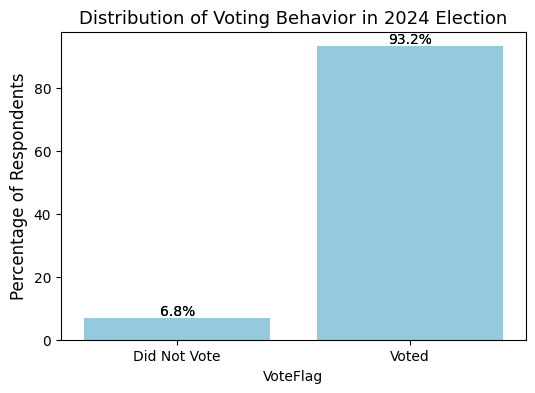

In [20]:
# bar plot of target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='VoteFlag', data=Voting_df, stat="percent")
ax = sns.countplot(x='VoteFlag', data=Voting_df, stat="percent", color='skyblue')
plt.ylabel('Percentage of Respondents', fontsize=12)
plt.title('Distribution of Voting Behavior in 2024 Election', fontsize=13, weight=400)
plt.xticks([0, 1], ['Did Not Vote', 'Voted'])
# add percentage labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=10)

plt.show()

In [21]:
# check distribution of target variable
Voting_df['VoteFlag'].value_counts(normalize=True)

VoteFlag
True     0.932121
False    0.067879
Name: proportion, dtype: float64

### Readable Columns

In [22]:
# Index of all columns within the original dataset, pre-trimming

CES2024_COLUMNS = {
    # ── Identifiers & Weights ──
    "caseid": "Case ID",
    "tookpost": "Took post-election survey",
    "commonweight": "Common content weight (all respondents, adults)",
    "commonpostweight": "Common content post-election weight (both waves, adults)",
    "vvweight": "Vote validation weight (matched to registration, registered adults)",
    "vvweight_post": "Vote validation post weight (both waves & matched, registered adults)",

    # ── Consent & Address ──
    "CCEStake": "Consent to participate",
    "add_confirm": "Confirm address",
    "inputzip": "Input zip code",

    # ── Demographics ──
    "birthyr": "Birth Year",                    # Age = 2024 - birthyr
    "gender4": "Gender",
    "gender4_t": "Gender (text)",
    "educ": "Education",                        # (Include in naive model)
    "race": "Race",
    "race_other": "Race - Other (text)",        # DROP
    "hispanic": "Hispanic",

    # ── Multiracial (check all) ──
    "multrace_1": "Multiracial - White",
    "multrace_2": "Multiracial - Black",
    "multrace_3": "Multiracial - Hispanic",
    "multrace_4": "Multiracial - Asian",
    "multrace_5": "Multiracial - Native American",
    "multrace_8": "Multiracial - Middle Eastern",
    "multrace_97": "Multiracial - Other",
    "multrace_98": "Multiracial - Don't know",

    # ── Device & Registration ──
    "comptype": "Device type",
    "votereg": "Voter Registration Status",
    "votereg_f": "Registered to vote (zip confirmation)",
    "regzip": "Registered zip code",

    # ── Party ID ──
    "pid3": "3 point party ID",
    "pid3_t": "3 point party ID (text)",
    "pid7": "7 point Party ID",

    # ── Geography ──
    "inputstate": "State of Residence",
    "region": "Region",
    "ccesmodule": "Team module assigned",

    # ── Media use past 24 hrs (check all) ──
    "CC24_300_1": "Media use past 24 hrs - Used social media",
    "CC24_300_2": "Media use past 24 hrs - Watched TV news",
    "CC24_300_3": "Media use past 24 hrs - Read a newspaper",
    "CC24_300_4": "Media use past 24 hrs - Listened to radio news",
    "CC24_300_5": "Media use past 24 hrs - None of these",

    # ── Media use follow-ups ──
    "CC24_300a": "Media use - TV news type",
    "CC24_300c": "Media use - Newspaper type",

    # ── Media use networks (check all) ──
    "CC24_300b_1": "Media networks - ABC",
    "CC24_300b_2": "Media networks - CBS",
    "CC24_300b_3": "Media networks - NBC",
    "CC24_300b_4": "Media networks - CNN",
    "CC24_300b_5": "Media networks - Fox News",
    "CC24_300b_6": "Media networks - MSNBC",
    "CC24_300b_7": "Media networks - PBS",
    "CC24_300b_8": "Media networks - Other",

    # ── Recent social media use (check all) ──
    "CC24_300d_1": "Recent social media use - Posted a story, photo, video or link about politics",
    "CC24_300d_2": "Recent social media use - Posted a comment about politics",
    "CC24_300d_3": "Recent social media use - Read a story or watched a video about politics",
    "CC24_300d_4": "Recent social media use - Followed a political event",
    "CC24_300d_5": "Recent social media use - Forwarded a story, photo, video or link about politics to friends",
    "CC24_300d_6": "Recent social media use - None of the above",

    # ── Economic perceptions ──
    "CC24_301": "National Economics",
    "CC24_302": "Household income change",
    "CC24_303": "Price change in past year",

    # ── Life Changes (check all) ──
    "CC24_305_1": "Life Changes - Married",
    "CC24_305_2": "Life Changes - Lost a job",
    "CC24_305_3": "Life Changes - Finished school",
    "CC24_305_4": "Life Changes - Retired",
    "CC24_305_5": "Life Changes - Divorced",
    "CC24_305_6": "Life Changes - Had a child",
    "CC24_305_7": "Life Changes - Taken a new job",
    "CC24_305_9": "Life Changes - Been a victim of a crime",
    "CC24_305_10": "Life Changes - Visited an emergency room",
    "CC24_305_11": "Life Changes - Visited a doctor for a regular examination",
    "CC24_305_12": "Life Changes - Received a raise at work",
    "CC24_305_13": "Life Changes - Had a pay cut at work",
    "CC24_305_14": "Life Changes - None of the above",

    # ── Health ──
    "CC24_309e": "General health",

    # ── Ukraine (check all) ──
    "CC24_308a_1": "Ukraine - Do not get involved",
    "CC24_308a_2": "Ukraine - Send food, medicine, and other humanitarian aid to Ukraine",
    "CC24_308a_3": "Ukraine - Impose economic sanctions on Russia",
    "CC24_308a_4": "Ukraine - Provide arms to Ukraine",
    "CC24_308a_5": "Ukraine - Send military support staff to Ukraine (non-combat)",
    "CC24_308a_6": "Ukraine - Send significant force to fight Russia",
    "CC24_308a_7": "Ukraine - Negotiate a peace accord between Russia and Ukraine",
    "CC24_308a_8": "Ukraine - Send aid to affected communities after the conflict to help rebuild",

    # ── Israel/Gaza (check all) ──
    "CC24_308b_1": "Israel/Gaza - Do not get involved",
    "CC24_308b_2": "Israel/Gaza - Send food, medicine and other aid to the communities affected",
    "CC24_308b_3": "Israel/Gaza - Provide arms to Israel",
    "CC24_308b_4": "Israel/Gaza - Provide arms to Hamas",
    "CC24_308b_5": "Israel/Gaza - Send the US Navy and troops to the region",
    "CC24_308b_6": "Israel/Gaza - Send military support staff (non-combat) to Israel",
    "CC24_308b_7": "Israel/Gaza - Send military support staff (non-combat) to Gaza",
    "CC24_308b_8": "Israel/Gaza - Negotiate a peace settlement",
    "CC24_308b_9": "Israel/Gaza - Send aid to affected communities after the conflict",

    # ── Emergency expense (check all) ──
    "CC24_309d_1": "Emergency expense - Put it on credit card, pay off in full",
    "CC24_309d_2": "Emergency expense - Put it on credit card, pay off over time",
    "CC24_309d_3": "Emergency expense - With checking/savings or cash",
    "CC24_309d_4": "Emergency expense - Bank loan or line of credit",
    "CC24_309d_5": "Emergency expense - Borrowing from friend or family",
    "CC24_309d_6": "Emergency expense - Payday loan, deposit advance, or overdraft",
    "CC24_309d_7": "Emergency expense - By selling something",
    "CC24_309d_8": "Emergency expense - Wouldn't be able to pay right now",
    "CC24_309d_9": "Emergency expense - Other",
    "CC24_309d_t": "Emergency expense - Other (text)",

    # ── Know Party in Government (grid) ──
    "CC24_310a": "Know Party in Government - U.S. House of Representatives",
    "CC24_310b": "Know Party in Government - U.S. Senate",
    "CC24_310c": "Know Party in Government - State Senate",
    "CC24_310d": "Know Party in Government - State Lower Chamber",

    # ── Know Party of Representative (grid) ──
    "CC24_311a": "Know Party of Representative - Governor",
    "CC24_311b": "Know Party of Representative - Senator 1",
    "CC24_311c": "Know Party of Representative - Senator 2",
    "CC24_311d": "Know Party of Representative - U.S. House member",

    # ── Job Approval Institutions (grid) ──
    "CC24_312a": "Job Approval - President Biden",
    "CC24_312i": "Job Approval - Vice President Harris",
    "CC24_312b": "Job Approval - U.S. Congress",
    "CC24_312c": "Job Approval - U.S. Supreme Court",
    "CC24_312d": "Job Approval - Governor",
    "CC24_312e": "Job Approval - State Legislature",
    "CC24_312f": "Job Approval - U.S. House member",
    "CC24_312g": "Job Approval - Senator 1",
    "CC24_312h": "Job Approval - Senator 2",

    # ── Citizenship & Immigration ──
    "cit1": "US citizen",
    "immstat": "Immigration background",

    # ── Gun control (grid) ──
    "CC24_321a": "Gun control - Ban assault rifles",
    "CC24_321b": "Gun control - Make it easier to obtain concealed-carry permit",
    "CC24_321c": "Gun control - Require background checks on all gun sales",
    "CC24_321d": "Gun control - Increase police on the street by 10 percent",
    "CC24_321e": "Gun control - Decrease police on the street by 10 percent",
    "CC24_321f": "Gun control - Increase spending on mental health and school safety; confiscate guns from dangerous persons; prohibit domestic violence convicts from owning guns; increase penalties for illegal gun purchases",

    # ── Immigration policy (grid) ──
    "CC24_323a": "Immigration - Grant legal status to illegal immigrants with jobs/taxes for 3 yrs",
    "CC24_323b": "Immigration - Increase border patrols on US-Mexican border",
    "CC24_323c": "Immigration - Build a wall between U.S. and Mexico",
    "CC24_323d": "Immigration - Provide permanent resident status to Dreamers",

    # ── Abortion (grid) ──
    "CC24_324a": "Abortion - Always allow as a matter of choice",
    "CC24_324b": "Abortion - Permit only in case of rape, incest, or life in danger",
    "CC24_324c": "Abortion - Make abortions illegal in all circumstances",
    "CC24_324d": "Abortion - Expand access to abortion",
    "CC24_325": "Abortion Month (until what week should abortion be legal)",

    # ── Environment (grid) ──
    "CC24_326a": "Environment - Give EPA power to regulate carbon dioxide emissions",
    "CC24_326b": "Environment - Require 20% electricity from renewable sources",
    "CC24_326c": "Environment - Strengthen EPA enforcement of Clean Air/Water Act",
    "CC24_326d": "Environment - Increase fossil fuel production in the U.S.",
    "CC24_326e": "Environment - Halt new oil and gas leases on federal lands",
    "CC24_326f": "Environment - Prevent government from banning gas stoves",

    # ── Tax/spending policies (grid) ──
    "CC24_328a": "Tax policies - Relax local zoning laws for more apartments/condos",
    "CC24_328b": "Tax policies - Expand federal tax incentives for affordable housing",
    "CC24_328c": "Tax policies - Require able-bodied adults to work for Medicaid",
    "CC24_328d": "Tax policies - Repeal the Affordable Care Act",
    "CC24_328e": "Tax policies - Expand Medicaid for low income individuals/families",
    "CC24_323f": "Tax policies - Forgive up to $20,000 of student loan debt",

    # ── Rate ideology (grid) ──
    "CC24_330a": "Rate ideology - Yourself",
    "CC24_330b": "Rate ideology - Governor",
    "CC24_330c": "Rate ideology - Joe Biden",
    "CC24_330d": "Rate ideology - Kamala Harris",
    "CC24_330e": "Rate ideology - Donald Trump",
    "CC24_330f": "Rate ideology - The Democratic Party",
    "CC24_330g": "Rate ideology - The Republican Party",
    "CC24_330h": "Rate ideology - The U.S. Supreme Court",
    "CC24_330i": "Rate ideology - Senator 1",
    "CC24_330j": "Rate ideology - Senator 2",
    "CC24_330l": "Rate ideology - U.S. House member",

    # ── Congress Bills (grid) ──
    "CC24_340a": "Congress Bills - Prohibit restrictions on contraceptives",
    "CC24_340b": "Congress Bills - Prohibit restrictions on abortion services",
    "CC24_340c": "Congress Bills - Require agencies recognize same-sex and interracial marriages",
    "CC24_340d": "Congress Bills - Ban TikTok unless China sells to US company",
    "CC24_340e": "Congress Bills - Renew federal surveillance programs (post-9/11)",
    "CC24_340f": "Congress Bills - Deny asylum for illegal border crossers",

    # ── Tax rates (grid) ──
    "CC24_341a": "Tax rates - Extend 2017 tax cuts",
    "CC24_341b": "Tax rates - Raise corporate income tax from 21% to 28%",
    "CC24_341c": "Tax rates - Allow tax rates on $400K+ earners to rise to 35%",
    "CC24_341d": "Tax rates - Spend $150B/yr for 8 yrs on infrastructure",

    # ── Party registration & past vote ──
    "CC24_361b": "Party Registration",
    "CC24_360_t": "Party Registration (text)",
    "presvote20post": "2020 President Vote Post Election",
    "presvote20post_t": "2020 President Vote Post Election (text)",

    # ── Pre-election vote intention & preferences ──
    "CC24_363": "Vote Intention",
    "CC24_364a": "Pres vote (pre-election)",
    "CC24_365_voted": "Senate vote (pre-election)",
    "CC24_365_voted_t": "Senate vote (pre-election, text)",
    "CC24_365b_voted": "Senate vote 2nd race (pre-election)",
    "CC24_365b_voted_t": "Senate vote 2nd race (pre-election, text)",
    "CC24_366_voted": "Governor vote (pre-election)",
    "CC24_366_voted_t": "Governor vote (pre-election, text)",
    "CC24_367_voted": "House vote (pre-election)",
    "CC24_367_voted_t": "House vote (pre-election, text)",
    "CC24_364b": "Pres preference",
    "CC24_365": "Senate preference",
    "CC24_365_t": "Senate preference (text)",
    "CC24_365a": "Senate second preference",
    "CC24_365a_t": "Senate second preference (text)",
    "CC24_365b": "Senate preference 2nd race",
    "CC24_365b_t": "Senate preference 2nd race (text)",
    "CC24_365c": "Senate second preference 2nd race",
    "CC24_365c_t": "Senate second preference 2nd race (text)",
    "CC24_366": "Governor preference",
    "CC24_366_t": "Governor preference (text)",
    "CC24_367": "House preference",
    "CC24_367_t": "House preference (text)",
    "CC24_367a": "House second choice",
    "CC24_367a_t": "House second choice (text)",

    # ── Residency & community ──
    "CC24_368": "Residency",
    "urbancity": "Type of Area Living In",
    "urbancity_t": "Type of Area Living In (text)",
    "ideo5": "Ideology",

    # ── Parenting ──
    "parent_1": "Parent - Yes, of at least one child younger than 18",
    "parent_2": "Parent - Yes, of at least one child 18 or older",
    "parent_97": "Parent - No, neither a parent nor guardian",
    "child18": "Children under age 18 in household",

    # ── Employment ──
    "employ": "Employment Status",
    "employ_t": "Employment Status (text)",
    "hadjob": "Had job in past 5 years",
    "investor": "Stock ownership",

    # ── Religion ──
    "pew_bornagain": "Born Again (Pew version)",
    "pew_religimp": "Importance of religion (Pew version)",
    "pew_churatd": "Church attendance (Pew version)",
    "pew_prayer": "Frequency of Prayer (Pew version)",
    "religpew": "Religion",
    "religpew_t": "Religion (text)",
    "religpew_protestant": "Protestant Church",
    "religpew_protestant_t": "Protestant Church (text)",
    "religpew_baptist": "Baptist Church",
    "religpew_baptist_t": "Baptist Church (text)",
    "religpew_methodist": "Methodist Church",
    "religpew_methodist_t": "Methodist Church (text)",
    "religpew_nondenom": "Nondenominational or Independent Church",
    "religpew_nondenom_t": "Nondenominational or Independent Church (text)",
    "religpew_lutheran": "Lutheran Church",
    "religpew_lutheran_t": "Lutheran Church (text)",
    "religpew_presby": "Presbyterian Church",
    "religpew_presby_t": "Presbyterian Church (text)",
    "religpew_pentecost": "Pentecostal Church",
    "religpew_pentecost_t": "Pentecostal Church (text)",
    "religpew_episcop": "Episcopal Church",
    "religpew_episcop_t": "Episcopal Church (text)",
    "religpew_christian": "Christian Church",
    "religpew_christian_t": "Christian Church (text)",
    "religpew_congreg": "Congregational Church",
    "religpew_congreg_t": "Congregational Church (text)",
    "religpew_holiness": "Holiness Church",
    "religpew_holiness_t": "Holiness Church (text)",
    "religpew_reformed": "Reformed Church",
    "religpew_reformed_t": "Reformed Church (text)",
    "religpew_advent": "Adventist Church",
    "religpew_advent_t": "Adventist Church (text)",
    "religpew_catholic": "Catholic Church",
    "religpew_catholic_t": "Catholic Church (text)",
    "religpew_mormon": "Mormon Church",
    "religpew_mormon_t": "Mormon Church (text)",
    "religpew_orthodox": "Orthodox Church",
    "religpew_orthodox_t": "Orthodox Church (text)",
    "religpew_jewish": "Jewish Group",
    "religpew_jewish_t": "Jewish Group (text)",
    "religpew_muslim": "Muslim Group",
    "religpew_muslim_t": "Muslim Group (text)",
    "religpew_buddhist": "Buddhist group",
    "religpew_buddhist_t": "Buddhist group (text)",
    "religpew_hindu": "Hindu Group",
    "religpew_hindu_t": "Hindu Group (text)",

    # ── Marital & Union ──
    "marstat": "Marital Status",
    "union": "Labor union member",
    "union_coverage": "Covered by union contract",
    "unionhh": "Family labor union member",
    "ownhome": "Home ownership",
    "ownhome_t": "Home ownership (text)",

    # ── Political interest & income ──
    "newsint": "Political Interest",
    "faminc_new": "Family income",

    # ── Military Household (check all) ──
    "milstat_1": "Military Household - I am currently serving",
    "milstat_2": "Military Household - Family member currently serving",
    "milstat_3": "Military Household - I served previously",
    "milstat_4": "Military Household - Family member served previously",
    "milstat_5": "Military Household - None",

    # ── Health insurance (check all) ──
    "healthins_1": "Health insurance - Through job",
    "healthins_2": "Health insurance - Government program",
    "healthins_3": "Health insurance - Through school",
    "healthins_4": "Health insurance - Purchase on own",
    "healthins_5": "Health insurance - Not sure",
    "healthins_6": "Health insurance - No",

    # ── Middle Eastern or North African ──
    "mena": "Middle Eastern or North African",
    "mena_origin_1": "MENA heritage - Afghan",
    "mena_origin_2": "MENA heritage - Egyptian",
    "mena_origin_3": "MENA heritage - Iranian",
    "mena_origin_4": "MENA heritage - Iraqi",
    "mena_origin_5": "MENA heritage - Israeli",
    "mena_origin_6": "MENA heritage - Lebanese",
    "mena_origin_7": "MENA heritage - Moroccan",
    "mena_origin_8": "MENA heritage - Palestinian",
    "mena_origin_9": "MENA heritage - Somali",
    "mena_origin_10": "MENA heritage - Syrian",
    "mena_origin_11": "MENA heritage - Turkish",
    "mena_origin_12": "MENA heritage - Other",
    "mena_origin_t": "MENA heritage (text)",

    # ── Latin heritage (check all) ──
    "CC24_hisp_1": "Latin heritage - No Country in Particular",
    "CC24_hisp_2": "Latin heritage - United States",
    "CC24_hisp_3": "Latin heritage - Mexico",
    "CC24_hisp_4": "Latin heritage - Puerto Rico",
    "CC24_hisp_5": "Latin heritage - Cuba",
    "CC24_hisp_6": "Latin heritage - Dominican Republic",
    "CC24_hisp_7": "Latin heritage - South America",
    "CC24_hisp_8": "Latin heritage - Central America",
    "CC24_hisp_9": "Latin heritage - Caribbean",
    "CC24_hisp_10": "Latin heritage - Spain",
    "CC24_hisp_11": "Latin heritage - Other",
    "CC24_hisp_12": "Latin heritage - I am not of Latino/Hispanic/Spanish heritage",
    "CC24_hisp_t": "Latin heritage (text)",

    # ── Asian heritage (check all) ──
    "CC24_asian_1": "Asian heritage - No Country in Particular",
    "CC24_asian_2": "Asian heritage - United States",
    "CC24_asian_3": "Asian heritage - China",
    "CC24_asian_4": "Asian heritage - Japan",
    "CC24_asian_5": "Asian heritage - India",
    "CC24_asian_6": "Asian heritage - Philippines",
    "CC24_asian_7": "Asian heritage - Taiwan",
    "CC24_asian_8": "Asian heritage - Korea",
    "CC24_asian_9": "Asian heritage - Vietnam",
    "CC24_asian_10": "Asian heritage - Pakistan",
    "CC24_asian_11": "Asian heritage - Hmong",
    "CC24_asian_12": "Asian heritage - Cambodia",
    "CC24_asian_13": "Asian heritage - Thailand",
    "CC24_asian_14": "Asian heritage - Other",
    "CC24_asian_15": "Asian heritage - I am not of Asian Heritage",
    "CC24_asian_t": "Asian heritage (text)",

    # ── Native American ──
    "CC24_native": "Native American heritage",

    # ── Past presidential vote ──
    "presvote16post": "2016 President Vote Post Election",
    "presvote16post_t": "2016 President Vote Post Election (text)",

    # ── Employment details ──
    "industry": "Industry",
    "jobnum": "Number of jobs",

    # ── Identity ──
    "sexuality": "Sexual Orientation",
    "transgender": "Transgender",

    # ── District/Geography (pre-election) ──
    "cdid118": "Congressional district ID (118th Congress)",
    "cdid119": "Congressional district ID (119th Congress)",
    "lookupzip": "Lookup zip code",
    "countyfips": "County FIPS code",
    "countyname": "County name",

    # ── Contextual: current officeholders & candidates (pre-election) ──
    "LegName": "State Legislature name",
    "LowerChamberName": "State Lower Chamber name",
    "UpperChamberName": "State Upper Chamber name",
    "CurrentGovName": "Current Governor name",
    "CurrentGovParty": "Current Governor party",
    "CurrentHouseName": "Current U.S. House member name",
    "CurrentHouseParty": "Current U.S. House member party",
    "CurrentSen1Name": "Current Senator 1 name",
    "CurrentSen1Party": "Current Senator 1 party",
    "CurrentSen2Name": "Current Senator 2 name",
    "CurrentSen2Party": "Current Senator 2 party",
    "GovCand1Name": "Governor candidate 1 name",
    "GovCand1Party": "Governor candidate 1 party",
    "GovCand2Name": "Governor candidate 2 name",
    "GovCand2Party": "Governor candidate 2 party",
    "GovCand3Name": "Governor candidate 3 name",
    "GovCand3Party": "Governor candidate 3 party",
    "HouseCand1Name": "House candidate 1 name",
    "HouseCand1Party": "House candidate 1 party",
    "HouseCand2Name": "House candidate 2 name",
    "HouseCand2Party": "House candidate 2 party",
    "HouseCand3Name": "House candidate 3 name",
    "HouseCand3Party": "House candidate 3 party",
    "HouseCand4Name": "House candidate 4 name",
    "HouseCand4Party": "House candidate 4 party",
    "HouseCand5Name": "House candidate 5 name",
    "HouseCand5Party": "House candidate 5 party",
    "SenCand1Name": "Senate candidate 1 name",
    "SenCand1Party": "Senate candidate 1 party",
    "SenCand2Name": "Senate candidate 2 name",
    "SenCand2Party": "Senate candidate 2 party",
    "SenCand3Name": "Senate candidate 3 name",
    "SenCand3Party": "Senate candidate 3 party",
    "SenCand1Name2": "Senate candidate 1 name (2nd race)",
    "SenCand1Party2": "Senate candidate 1 party (2nd race)",
    "SenCand2Name2": "Senate candidate 2 name (2nd race)",
    "SenCand2Party2": "Senate candidate 2 party (2nd race)",

    # ── Page timing (pre-election) ──
    "page_CC24_300_timing": "Page timing - Media use past 24 hrs",
    "page_CC24_300b_timing": "Page timing - Media use networks",
    "page_CC24_300d_timing": "Page timing - Recent social media use",
    "page_CC24_301_timing": "Page timing - National Economics",
    "page_CC24_302_timing": "Page timing - Household income change",
    "page_CC24_303_timing": "Page timing - Price change in past year",
    "page_employ_timing": "Page timing - Employment Status",
    "page_CC24_305_timing": "Page timing - Life Changes",
    "page_CC24_309e_timing": "Page timing - General health",
    "page_CC24_308a_timing": "Page timing - Ukraine",
    "page_CC24_308b_timing": "Page timing - Israel/Gaza",
    "page_CC24_309d_timing": "Page timing - Emergency expense",
    "page_CC24_310grid_timing": "Page timing - Know Party in Government",
    "page_pageCC24_311grid_timing": "Page timing - Know Party of Representative",
    "page_CC24_312grid_timing": "Page timing - Job Approval Institutions",
    "page_cit1_timing": "Page timing - US citizen",
    "page_immstat_timing": "Page timing - Immigration background",
    "page_CC24_321grid_timing": "Page timing - Gun control",
    "page_CC24_323grid_timing": "Page timing - Immigration policy",
    "page_CC24_324grid_timing": "Page timing - Abortion",
    "page_CC24_325_timing": "Page timing - Abortion Month",
    "page_CC24_326grid_timing": "Page timing - Environment",
    "page_CC24_328grid_timing": "Page timing - Tax policies",
    "page_CC24_330grid_timing": "Page timing - Rate ideology",
    "page_CC24_340grid_timing": "Page timing - Congress Bills",
    "page_CC24_341grid_timing": "Page timing - Tax rates",
    "page_CC24_361b_timing": "Page timing - Party Registration",
    "page_presvote20post_timing": "Page timing - 2020 President Vote",
    "page_CC24_363_timing": "Page timing - Vote Intention",
    "page_CC24_364a_timing": "Page timing - Pres vote (pre-election)",
    "page_CC24_365_voted_timing": "Page timing - Senate vote (pre-election)",
    "page_CC24_365b_voted_timing": "Page timing - Senate vote 2nd race (pre-election)",
    "page_CC24_366_voted_timing": "Page timing - Governor vote (pre-election)",
    "page_CC24_367_voted_timing": "Page timing - House vote (pre-election)",
    "page_CC24_364b_timing": "Page timing - Pres preference",
    "page_CC24_365_timing": "Page timing - Senate preference",
    "page_CC24_365a_timing": "Page timing - Senate second preference",
    "page_CC24_365b_timing": "Page timing - Senate preference 2nd race",
    "page_CC24_365c_timing": "Page timing - Senate second preference 2nd race",
    "page_CC24_366_timing": "Page timing - Governor preference",
    "page_CC24_367_timing": "Page timing - House preference",
    "page_CC24_367a_timing": "Page timing - House second choice",
    "page_CC24_368_timing": "Page timing - Residency",
    "page_urbancity_timing": "Page timing - Type of Area Living In",
    "page_ideo5_timing": "Page timing - Ideology",
    "page_parent_timing": "Page timing - Parent",
    "page_child18_timing": "Page timing - Children under 18",
    "page_hadjob_timing": "Page timing - Had job in past 5 years",
    "page_investor_timing": "Page timing - Stock ownership",
    "page_pew_bornagain_timing": "Page timing - Born Again",
    "page_pew_religimp_timing": "Page timing - Importance of religion",
    "page_pew_churatd_timing": "Page timing - Church attendance",
    "page_pew_prayer_timing": "Page timing - Frequency of Prayer",
    "page_religpew_timing": "Page timing - Religion",
    "page_religpew_protestant_timing": "Page timing - Protestant Church",
    "page_religion_denom_timing": "Page timing - Religion denomination",
    "page_marstat_timing": "Page timing - Marital Status",
    "page_union_timing": "Page timing - Labor union member",
    "page_union_coverage_timing": "Page timing - Union contract coverage",
    "page_unionhh_timing": "Page timing - Family labor union member",
    "page_ownhome_timing": "Page timing - Home ownership",
    "page_demos2c_timing": "Page timing - Demographics 2c",
    "page_milstat_timing": "Page timing - Military Household",
    "page_healthins_timing": "Page timing - Health insurance",
    "page_mena_timing": "Page timing - Middle Eastern or North African",
    "page_mena_origin_timing": "Page timing - MENA Country of Origin",
    "page_CC24_hisp_timing": "Page timing - Latin heritage",
    "page_CC24_asian_timing": "Page timing - Asian heritage",
    "page_CC24_native_timing": "Page timing - Native American heritage",
    "page_presvote16post_timing": "Page timing - 2016 President Vote",
    "page_industry_timing": "Page timing - Industry",
    "page_jobnum_timing": "Page timing - Number of jobs",
    "page_sex_timing": "Page timing - Sexual Orientation",

    # ── Post-election: registration & demographics ──
    "regzip_confirm_post": "Confirm registered zip code post",
    "reszip_confirm_post": "Confirm zip code post",
    "inputzip_post": "Input zip code (post)",
    "votereg_post": "Voter Registration Status post",
    "votereg_f_post": "Registered to vote post",
    "regzip_post": "Registered zip code (post)",
    "inputstate_post": "State post",
    "birthyr_post": "Birth Year (post)",
    "gender4_post": "Gender (post)",

    # ── Post-election: Party ID ──
    "CC24_433a": "3 pt party ID (post)",
    "CC24_433_t": "3 pt party ID (post, text)",
    "CC24_433_dem": "Party ID Dem strength",
    "CC24_433_rep": "Party ID Rep strength",
    "CC24_433b": "Party ID lean",
    "CC24_pid7": "7 point Party ID (post)",

    # ── Turnout ──
    "CC24_401": "Voted in 2024 General election",
    "CC24_402a": "Main reason didn't vote",
    "CC24_402a_t": "Main reason didn't vote (text)",
    "CC24_402b": "Second reason didn't vote",
    "CC24_402b_t": "Second reason didn't vote (text)",
    "CC24_402c": "Main reason no past vote",
    "CC24_402c_t": "Main reason no past vote (text)",

    # ── Vote method ──
    "CC24_403": "Vote in person or by mail",
    "CC24_403b": "Vote at precinct polling place or vote center",
    "CC24_403c": "Where absentee ballot returned",
    "CC24_403c_t": "Where absentee ballot returned (text)",
    "CC24_403d": "How long it took to return mail ballot",
    "CC24_403d_t": "How long it took to return mail ballot (text)",
    "CC24_404": "Voting length wait time",
    "CC24_404_t": "Voting length wait time (text)",
    "CC24_405": "Registered to vote on Election Day",

    # ── Voting problems ──
    "CC24_406a": "Problem with voter registration or ID when trying to vote",
    "CC24_406b_1": "Problem with voting - ID",
    "CC24_406b_2": "Problem with voting - Registration",
    "CC24_406b_3": "Problem with voting - Wrong place",
    "CC24_406b_4": "Problem with voting - Other",
    "CC24_406b_t": "Problem with voting (text)",
    "CC24_406c": "Allowed to vote",

    # ── Post-election vote choice ──
    "CC24_410": "Pres vote post",
    "CC24_410_t": "Pres vote post (text)",
    "CC24_411": "Senate vote post",
    "CC24_411_t": "Senate vote post (text)",
    "CC24_411b": "Senate vote 2nd race post",
    "CC24_411b_t": "Senate vote 2nd race post (text)",
    "CC24_412": "House vote post",
    "CC24_412_t": "House vote post (text)",
    "CC24_413": "Governor vote post",
    "CC24_413_t": "Governor vote post (text)",

    # ── Post-election: non-voter preferences ──
    "CC24_410_nv": "President prefer (non-voter)",
    "CC24_410_nv_t": "President prefer (non-voter, text)",
    "CC24_411_nv": "Senator prefer (non-voter)",
    "CC24_411_nv_t": "Senator prefer (non-voter, text)",
    "CC24_411b_nv": "Senator prefer 2nd race (non-voter)",
    "CC24_411b_nv_t": "Senator prefer 2nd race (non-voter, text)",
    "CC24_412_nv": "House prefer (non-voter)",
    "CC24_412_nv_t": "House prefer (non-voter, text)",
    "CC24_413_nv": "Governor prefer (non-voter)",
    "CC24_413_nv_t": "Governor prefer (non-voter, text)",

    # ── Statewide races ──
    "CC24_414a": "State Vote - Attorney General",
    "CC24_414b": "State Vote - Secretary of State",

    # ── State legislature vote ──
    "CC24_415c": "Vote State legislature - State Senate",
    "CC24_415d": "Vote State legislature - State Lower Chamber",

    # ── Race/ethnicity of politicians ──
    "CC24_416a": "Race/ethnicity politicians - House candidate 1",
    "CC24_416b": "Race/ethnicity politicians - House candidate 2",
    "CC24_416c": "Race/ethnicity politicians - Current U.S. House member",
    "CC24_416a_other": "Race/ethnicity politicians - House candidate 1 (other text)",
    "CC24_416b_other": "Race/ethnicity politicians - House candidate 2 (other text)",
    "CC24_416c_other": "Race/ethnicity politicians - Current House member (other text)",

    # ── Use U.S. military troops (check all) ──
    "CC24_420_1": "Use U.S. military troops - Ensure the supply of oil",
    "CC24_420_2": "Use U.S. military troops - Destroy a terrorist camp",
    "CC24_420_3": "Use U.S. military troops - Intervene in genocide or civil war",
    "CC24_420_4": "Use U.S. military troops - Assist the spread of democracy",
    "CC24_420_5": "Use U.S. military troops - Protect American allies under attack",
    "CC24_420_6": "Use U.S. military troops - Help the UN uphold international law",
    "CC24_420_7": "Use U.S. military troops - None of the above",

    # ── Election fairness (grid) ──
    "CC24_421_1": "Election fair - Elections in the U.S. are fair",
    "CC24_421_2": "Election fair - State/local government conducted fair and accurate election in 2024",

    # ── Trust in government ──
    "CC24_423": "Trust in federal government",
    "CC24_424": "Trust in state government",

    # ── Past year political activities (check all) ──
    "CC24_430a_1": "Past year - Attend local political meetings",
    "CC24_430a_2": "Past year - Put up a political sign",
    "CC24_430a_3": "Past year - Work for a candidate or campaign",
    "CC24_430a_4": "Past year - Attend a political protest, march or demonstration",
    "CC24_430a_5": "Past year - Contact a public official",
    "CC24_430a_6": "Past year - Donate money to a candidate, campaign, or political organization",
    "CC24_430a_7": "Past year - Donate blood",
    "CC24_430a_8": "Past year - None of these",

    # ── Donate money (check all) ──
    "CC24_430b_1": "Donate money - Candidate for President",
    "CC24_430b_2": "Donate money - Candidate for U.S. Senate in my state",
    "CC24_430b_3": "Donate money - Candidate for U.S. Senate in another state",
    "CC24_430b_4": "Donate money - Candidate for U.S. House in my state",
    "CC24_430b_5": "Donate money - Candidate for U.S. House in another state",
    "CC24_430b_6": "Donate money - Candidate for state office",
    "CC24_430b_7": "Donate money - Political party committee",
    "CC24_430b_8": "Donate money - Political action committee at work",
    "CC24_430b_9": "Donate money - Political group",
    "CC24_430b_10": "Donate money - Other",
    "CC24_430b_t": "Donate money (text)",
    "CC24_430c": "Donate money - total amount",

    # ── Campaign contact ──
    "CC24_431a": "Contacted by candidate or political campaign",
    "CC24_431b_1": "Candidate contact method - In person",
    "CC24_431b_2": "Candidate contact method - Phone call",
    "CC24_431b_3": "Candidate contact method - Email or text message",
    "CC24_431b_4": "Candidate contact method - Letter or post card",

    # ── Run for office ──
    "CC24_432a": "Ever run for elective office",
    "CC24_432b_1": "Run for office - School Board",
    "CC24_432b_2": "Run for office - Other local board or commission",
    "CC24_432b_3": "Run for office - City Council",
    "CC24_432b_4": "Run for office - Mayor",
    "CC24_432b_5": "Run for office - City or District Attorney",
    "CC24_432b_6": "Run for office - Countywide office",
    "CC24_432b_7": "Run for office - State legislature",
    "CC24_432b_8": "Run for office - Statewide office",
    "CC24_432b_9": "Run for office - Federal legislature",
    "CC24_432b_10": "Run for office - Judge",
    "CC24_432b_11": "Run for office - Other",
    "CC24_432b_t": "Run for office (text)",

    # ── Racial/Sexual agreement (grid) ──
    "CC24_440a": "Racial/Sexual agreement - White people have advantages",
    "CC24_440b": "Racial/Sexual agreement - Racial problems are rare, isolated",
    "CC24_440c": "Racial/Sexual agreement - Women seek power by controlling men",
    "CC24_440d": "Racial/Sexual agreement - Women are too easily offended",

    # ── Racial Resentment (grid) ──
    "CC24_441a": "Racial Resentment - Blacks should work their way up without special favors",
    "CC24_441b": "Racial Resentment - Slavery/discrimination created conditions difficult for Blacks",
    "CC24_441e": "Racial Resentment - I resent when Whites deny racial discrimination",
    "CC24_441f": "Racial Resentment - Whites get away with offenses Blacks would not",
    "CC24_441g": "Racial Resentment - Whites do not understand problems African Americans face",

    # ── State legislature spending (grid) ──
    "CC24_443_1": "State legislature spending - Welfare",
    "CC24_443_2": "State legislature spending - Health Care",
    "CC24_443_3": "State legislature spending - Education",
    "CC24_443_4": "State legislature spending - Law Enforcement",
    "CC24_443_5": "State legislature spending - Transportation/Infrastructure",

    # ── State policies (grid) ──
    "CC24_444a": "State policies - Preventing gender transition surgery for minors",
    "CC24_444b": "State policies - Requiring parental consent for name/pronoun changes at school",
    "CC24_444c": "State policies - Prohibiting abortion-inducing drugs through mail",
    "CC24_444d": "State policies - Prohibiting traveling to another state for abortion",
    "CC24_444e": "State policies - Age verification for adult content online",
    "CC24_444f": "State policies - School voucher subsidies for private/charter schools",

    # ── Supreme Court decisions (grid) ──
    "CC24_445a": "Supreme Court - Use of race in university admissions is illegal",
    "CC24_445b": "Supreme Court - Constitution does not protect right to abortion (Roe overruled)",

    # ── Other post-election ──
    "gunown": "Personal gun ownership",
    "numchildren": "Number of children",
    "gigwork": "Gig work",
    "edloan": "Student debtor",
    "student": "Student Full or Part-time",

    # ── Post-election geography & contextual ──
    "lookupzip_post": "Lookup zip code (post)",
    "cdid118_post": "Congressional district ID 118th Congress (post)",
    "cdid119_post": "Congressional district ID 119th Congress (post)",
    "LegName_post": "State Legislature name (post)",
    "LowerChamberName_post": "State Lower Chamber name (post)",
    "CurrentGovName_post": "Current Governor name (post)",
    "CurrentGovParty_post": "Current Governor party (post)",
    "CurrentHouseName_post": "Current U.S. House member name (post)",
    "CurrentHouseParty_post": "Current U.S. House member party (post)",
    "CurrentSen1Name_post": "Current Senator 1 name (post)",
    "CurrentSen1Party_post": "Current Senator 1 party (post)",
    "CurrentSen2Name_post": "Current Senator 2 name (post)",
    "CurrentSen2Party_post": "Current Senator 2 party (post)",
    "GovCand1Name_post": "Governor candidate 1 name (post)",
    "GovCand1Party_post": "Governor candidate 1 party (post)",
    "GovCand2Name_post": "Governor candidate 2 name (post)",
    "GovCand2Party_post": "Governor candidate 2 party (post)",
    "GovCand3Name_post": "Governor candidate 3 name (post)",
    "GovCand3Party_post": "Governor candidate 3 party (post)",
    "HouseCand1Name_post": "House candidate 1 name (post)",
    "HouseCand1Party_post": "House candidate 1 party (post)",
    "HouseCand2Name_post": "House candidate 2 name (post)",
    "HouseCand2Party_post": "House candidate 2 party (post)",
    "HouseCand3Name_post": "House candidate 3 name (post)",
    "HouseCand3Party_post": "House candidate 3 party (post)",
    "HouseCand4Name_post": "House candidate 4 name (post)",
    "HouseCand4Party_post": "House candidate 4 party (post)",
    "HouseCand5Name_post": "House candidate 5 name (post)",
    "HouseCand5Party_post": "House candidate 5 party (post)",
    "SenCand1Name_post": "Senate candidate 1 name (post)",
    "SenCand1Party_post": "Senate candidate 1 party (post)",
    "SenCand2Name_post": "Senate candidate 2 name (post)",
    "SenCand2Party_post": "Senate candidate 2 party (post)",
    "SenCand3Name_post": "Senate candidate 3 name (post)",
    "SenCand3Party_post": "Senate candidate 3 party (post)",
    "SenCand1Name2_post": "Senate candidate 1 name 2nd race (post)",
    "SenCand1Party2_post": "Senate candidate 1 party 2nd race (post)",
    "SenCand2Name2_post": "Senate candidate 2 name 2nd race (post)",
    "SenCand2Party2_post": "Senate candidate 2 party 2nd race (post)",
    "AttCand1Name": "Attorney General candidate 1 name",
    "AttCand2Name": "Attorney General candidate 2 name",
    "AttCand3Name": "Attorney General candidate 3 name",
    "AttCand1Party": "Attorney General candidate 1 party",
    "AttCand2Party": "Attorney General candidate 2 party",
    "AttCand3Party": "Attorney General candidate 3 party",
    "SecCand1Name": "Secretary of State candidate 1 name",
    "SecCand2Name": "Secretary of State candidate 2 name",
    "SecCand3Name": "Secretary of State candidate 3 name",
    "SecCand1Party": "Secretary of State candidate 1 party",
    "SecCand2Party": "Secretary of State candidate 2 party",
    "SecCand3Party": "Secretary of State candidate 3 party",

    # ── Page timing (post-election) ──
    "page_CC24_401_timing": "Page timing - Voted in 2024 General election",
    "page_CC24_402a_timing": "Page timing - Main reason didn't vote",
    "page_CC24_402b_timing": "Page timing - Second reason didn't vote",
    "page_CC24_402c_timing": "Page timing - Main reason no past vote",
    "page_CC24_403_timing": "Page timing - Vote in person or by mail",
    "page_CC24_403c_timing": "Page timing - Where absentee ballot returned",
    "page_CC24_403d_timing": "Page timing - How long to return mail ballot",
    "page_CC24_404_timing": "Page timing - Voting length wait time",
    "page_CC24_405_timing": "Page timing - Registered to vote on Election Day",
    "page_CC24_406a_timing": "Page timing - Problem with voter registration/ID",
    "page_CC24_406b_timing": "Page timing - Problem with voting",
    "page_CC24_406c_timing": "Page timing - Allowed to vote",
    "page_CC24_410_timing": "Page timing - Pres vote post",
    "page_CC24_411_timing": "Page timing - Senate vote post",
    "page_CC24_411b_timing": "Page timing - Senate vote 2nd race post",
    "page_CC24_412_timing": "Page timing - House vote post",
    "page_CC24_413_timing": "Page timing - Governor vote post",
    "page_CC24_410_nv_timing": "Page timing - President prefer (non-voter)",
    "page_CC24_411_nv_timing": "Page timing - Senator prefer (non-voter)",
    "page_CC24_411b_nv_timing": "Page timing - Senator prefer 2nd race (non-voter)",
    "page_CC24_412_nv_timing": "Page timing - House prefer (non-voter)",
    "page_CC24_413_nv_timing": "Page timing - Governor prefer (non-voter)",
    "page_CC24_414a_timing": "Page timing - State Vote AG",
    "page_CC24_414b_timing": "Page timing - State Vote SOS",
    "page_CC24_415_grid_timing": "Page timing - Vote State legislature",
    "page_CC24_416_grid_timing": "Page timing - Race/ethnicity politicians",
    "page_CC24_416a_other_timing": "Page timing - Race/ethnicity House cand 1 other",
    "page_CC24_416b_other_timing": "Page timing - Race/ethnicity House cand 2 other",
    "page_CC24_416c_other_timing": "Page timing - Race/ethnicity current House member other",
    "page_CC24_420_timing": "Page timing - Use U.S. military troops",
    "page_CC24_421_grid_timing": "Page timing - Election fair",
    "page_CC24_423_timing": "Page timing - Trust in federal government",
    "page_CC24_424_timing": "Page timing - Trust in state government",
    "page_CC24_430a_timing": "Page timing - Past year political activities",
    "page_CC24_430b_timing": "Page timing - Donate money",
    "page_CC24_430c_timing": "Page timing - Donate money amount",
    "page_CC24_431a_timing": "Page timing - Contacted by campaign",
    "page_CC24_431b_timing": "Page timing - Candidate contact method",
    "page_CC24_432a_timing": "Page timing - Ever run for office",
    "page_CC24_432b_timing": "Page timing - Run for office details",
    "page_CC24_440_grid_timing": "Page timing - Racial/Sexual agreement",
    "page_CC24_441_grid_timing": "Page timing - Racial Resentment",
    "page_CC24_443_timing": "Page timing - State legislature spending",
    "page_CC24_444_timing": "Page timing - State policies",
    "page_CC24_445_timing": "Page timing - Supreme Court decisions",
    "page_gunown_timing": "Page timing - Personal gun ownership",
    "page_numchildren_timing": "Page timing - Number of children",
    "page_gigwork_timing": "Page timing - Gig work",
    "page_edloan_timing": "Page timing - Student debtor",
    "page_student_timing": "Page timing - Student status",

    # ── Timestamps ──
    "starttime": "Survey start time (pre-election)",
    "endtime": "Survey end time (pre-election)",
    "starttime_post": "Survey start time (post-election)",
    "endtime_post": "Survey end time (post-election)",

    # ── Vote Validation (TargetSmart) ──
    "TS_g2024": "Vote validation - 2024 general election vote method",
    "TS_voterstatus": "Vote validation - Voter registration status",
    "TS_p2024": "Vote validation - 2024 state primary vote method",
    "TS_p2024_party": "Vote validation - 2024 state primary party",
    "TS_pp2024": "Vote validation - 2024 presidential primary vote method",
    "TS_pp2024_party": "Vote validation - 2024 presidential primary party",
    "TS_state": "Vote validation - State matched",
    "TS_partyreg": "Vote validation - Party registration on file",
    
    # ── Engineered Features ──
    "VoteFlag": "Did Vote?",
    "IsParent": "Is Parent?",
    "VoterAge": "Age", #Computed as described at "BirthYr"
    "is_student": "Is Student?"
}


## Naive Model

As a starting place, using basic, easy to obtain information to predict turnout.

In [72]:
# selecting features for a naive model based on common predictors of voting behavior

naive_features = [
    'VoterAge',
    'gender4',
    'educ',
    'race',
    'hispanic',
    'pid3', # Party ID
    'inputstate',
    'region',
    'is_student',
]

In [73]:
# make df for naive model
naive_df = Voting_df[naive_features]
naive_df.head()

,VoterAge,gender4,educ,race,hispanic,pid3,inputstate,region,is_student
0,46,2,2,2,0,1,42,1,0
1,56,1,5,3,1,2,36,1,0
2,78,2,4,1,0,3,42,1,0
3,23,2,2,1,1,1,6,4,0
4,69,2,2,1,0,2,30,4,0


In [74]:
# identify categorical and numerical features
categorical_features = ['gender4', 'educ', 'race', 'hispanic', 'pid3', 'inputstate', 'region', 'is_student']
numerical_features = ['VoterAge']

In [75]:
# set X and Y
X = Voting_df[naive_features]
y = Voting_df['VoteFlag'].astype(int) # cat prefers 0/1 over bool, convert target to binary

# train and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [76]:
# build initial model
naive_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    cat_features=categorical_features,
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)

# fit model
naive_model.fit(X_train, y_train, eval_set=(X_test, y_test))

0:	test: 0.5314729	best: 0.5314729 (0)	total: 43.7ms	remaining: 43.7s
100:	test: 0.7855818	best: 0.7855818 (100)	total: 6.07s	remaining: 54s
200:	test: 0.7869314	best: 0.7869350 (194)	total: 12.2s	remaining: 48.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.787122209
bestIteration = 219

Shrink model to first 220 iterations.


CatBoostClassifier(cat_features=['gender4', 'educ', 'race', 'hispanic', 'pid3', 'inputstate', 'region', 'is_student'], depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=1000, learning_rate=0.05, random_seed=42, verbose=100)

In [77]:
# evaluate model
y_pred = naive_model.predict(X_test)
y_prob = naive_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.62      0.05      0.09       637
           1       0.94      1.00      0.97      8754

    accuracy                           0.93      9391
   macro avg       0.78      0.52      0.53      9391
weighted avg       0.91      0.93      0.91      9391

ROC-AUC: 0.7871


As predicted, the model had very low recall for non-voters (0.05). This is because of the large imbalance on voters and non-voters in the dataset.

In [78]:
# look at feature importance
feat_imp = pd.Series(naive_model.get_feature_importance(), index=naive_features).sort_values(ascending=False)
print("\nFeature Importances:")
print(feat_imp)


Feature Importances:
educ          26.562669
VoterAge      25.878784
pid3          14.638097
race           9.536315
inputstate     8.455677
gender4        6.864254
region         5.084972
hispanic       1.662887
is_student     1.316344
dtype: float64


### Trying again, accounting for class balance

In [79]:
# build model
naive_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    cat_features=categorical_features,
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100,
    # add class weights to address imbalance in target variable
    auto_class_weights='Balanced'
)

# fit model
naive_model.fit(X_train, y_train, eval_set=(X_test, y_test))

# evaluate model
y_pred = naive_model.predict(X_test)
y_prob = naive_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


0:	test: 0.7456453	best: 0.7456453 (0)	total: 58.7ms	remaining: 58.6s
100:	test: 0.7887272	best: 0.7887383 (99)	total: 6.59s	remaining: 58.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7887431769
bestIteration = 101

Shrink model to first 102 iterations.
              precision    recall  f1-score   support

           0       0.16      0.68      0.26       637
           1       0.97      0.75      0.84      8754

    accuracy                           0.74      9391
   macro avg       0.57      0.71      0.55      9391
weighted avg       0.92      0.74      0.80      9391

ROC-AUC: 0.7887


In [80]:
# look at feature importance
feat_imp = pd.Series(naive_model.get_feature_importance(), index=naive_features).sort_values(ascending=False)
print("\nFeature Importances:")
print(feat_imp)


Feature Importances:
VoterAge      27.198702
educ          27.073440
pid3          14.632808
gender4        9.217828
race           8.672171
inputstate     7.080650
region         4.007567
hispanic       1.393556
is_student     0.723277
dtype: float64


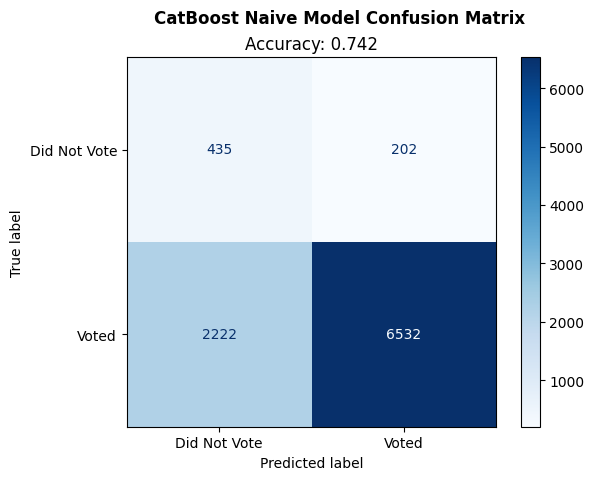

In [81]:
# create a confusion matrix
confusion_matrix_ex(y_test, y_pred, ["Did Not Vote", "Voted"], "CatBoost Naive Model")

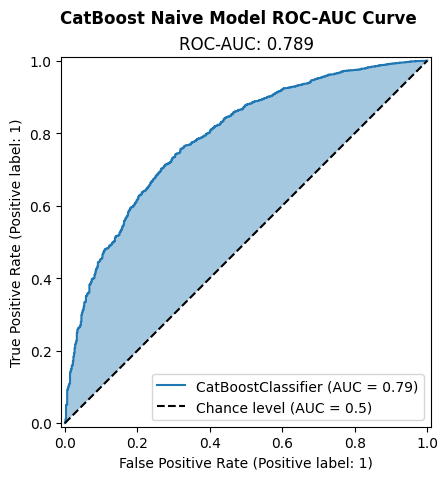

In [82]:
# ROC curve
roc_curve_display_ex(naive_model, X_test, y_test, "CatBoost Naive Model")


## Hyperparameter Tuning

In [102]:
# Defining Optuna function for CatBoost
def cb_objective(trial):
    param = {
        # "objective": trial.suggest_categorical("objective", ["Logloss", "CrossEntropy"]),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01, 0.1),
        "depth": trial.suggest_int("depth", 1, 12),
        "boosting_type": trial.suggest_categorical("boosting_type", ["Ordered", "Plain"]),
        'learning_rate': trial.suggest_float('learning_rate', 0.06, 0.09, log=True),
        'iterations': trial.suggest_int('iterations', 100, 1500),
        'eval_metric': 'F1',  # Set F1 as evaluation metric
        'random_strength': trial.suggest_float('random_strength', 0, 1.0),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 3, 10.0),
        'random_seed': 42,
        "auto_class_weights": "Balanced",
    }

    naive_model = CatBoostClassifier(**param)
    naive_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=0, early_stopping_rounds=50, cat_features=categorical_features)

    y_f1 = naive_model.predict(X_test)
    score = f1_score(y_test, y_f1, pos_label=0)   # F1 as optimization metric, 0 to maximize minority class F1
    return score

In [103]:
cb_study = optuna.create_study(study_name="catboost_study", direction='maximize') 
cb_study.optimize(cb_objective, n_trials=50, show_progress_bar=True, n_jobs=-1)
cb_best_params = cb_study.best_params   

[I 2026-03-13 18:26:16,192] A new study created in memory with name: catboost_study


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-13 18:26:19,943] Trial 3 finished with value: 0.24033149171270718 and parameters: {'colsample_bylevel': 0.02603381279868061, 'depth': 8, 'boosting_type': 'Ordered', 'learning_rate': 0.07735713849215745, 'iterations': 181, 'random_strength': 0.9606672672387437, 'l2_leaf_reg': 3.856630617656949}. Best is trial 3 with value: 0.24033149171270718.
[I 2026-03-13 18:26:27,978] Trial 7 finished with value: 0.17153284671532848 and parameters: {'colsample_bylevel': 0.021923946727000966, 'depth': 7, 'boosting_type': 'Plain', 'learning_rate': 0.07092238663435935, 'iterations': 957, 'random_strength': 0.35701363823249566, 'l2_leaf_reg': 3.784188499894416}. Best is trial 3 with value: 0.24033149171270718.
[I 2026-03-13 18:26:51,455] Trial 5 finished with value: 0.26658243840808593 and parameters: {'colsample_bylevel': 0.04478041669371293, 'depth': 11, 'boosting_type': 'Ordered', 'learning_rate': 0.0678337971702204, 'iterations': 1264, 'random_strength': 0.33012827251702814, 'l2_leaf_reg':

In [104]:
# add "auto_class_weights": "Balanced" to best params to address class imbalance
cb_best_params["auto_class_weights"] = "Balanced"
cb_best_params

{'colsample_bylevel': 0.09936433478086192,
 'depth': 12,
 'boosting_type': 'Plain',
 'learning_rate': 0.08928654274140355,
 'iterations': 1496,
 'random_strength': 0.29819992179324106,
 'l2_leaf_reg': 4.712289642616186,
 'auto_class_weights': 'Balanced'}

0:	learn: 0.6849977	test: 0.6855044	best: 0.6855044 (0)	total: 43.1ms	remaining: 1m 4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5805201775
bestIteration = 41

Shrink model to first 42 iterations.


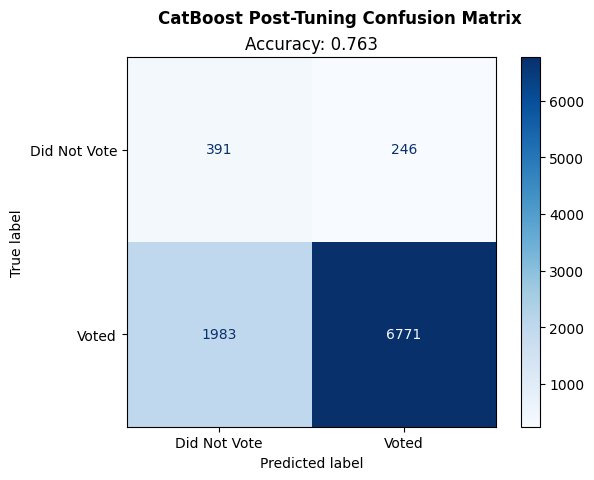

In [105]:
hyper_cb = CatBoostClassifier(**cb_best_params)
hyper_cb.fit(X_train, y_train, cat_features=categorical_features, eval_set=(X_test, y_test), verbose=100, early_stopping_rounds=50)

# Printing Confusion Matrix
y_pred = hyper_cb.predict(X_test)
confusion_matrix_ex(y_test, y_pred, ["Did Not Vote", "Voted"], "CatBoost Post-Tuning")

CatBoost Post-Tuning Accuracy: 0.7626450857203706
CatBoost Post-Tuning ROC-AUC: 0.7704658180032702

Classification Report:
               precision    recall  f1-score   support

           0       0.16      0.61      0.26       637
           1       0.96      0.77      0.86      8754

    accuracy                           0.76      9391
   macro avg       0.56      0.69      0.56      9391
weighted avg       0.91      0.76      0.82      9391



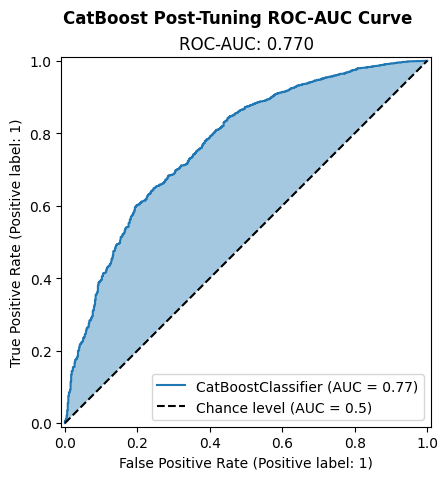

In [106]:
perf_output(hyper_cb, X_test, y_test, "CatBoost Post-Tuning")

## Adding Addtional Features

#### Define more comprehesive list of features

In [108]:

full_features = [
   # Copy from naive
    'VoterAge',         # Age (derived: 2024 - birthyr)
    'gender4',          # Gender
    'educ',             # Education
    'race',             # Race
    'hispanic',         # Hispanic
    'pid3',             # 3 point party ID
    'inputstate',       # State of Residence
    'region',           # Region
    'is_student',       # Student Full or Part-time (derived)

    # Multiracial categories
    "multrace_1",       # Multiracial - White
    "multrace_2",       # Multiracial - Black
    "multrace_3",       # Multiracial - Hispanic
    "multrace_4",       # Multiracial - Asian
    "multrace_5",       # Multiracial - Native American
    "multrace_8",       # Multiracial - Middle Eastern
    "multrace_97",      # Multiracial - Other
    "multrace_98",      # Multiracial - Don't know

    # Device & Registration
    'votereg',          # Voter Registration Status

    # Other
    'pid7',             # 7 point Party ID
    'immstat',          # Immigration background

    # Media consumption (past 24 hrs)
    "CC24_300_1",       # Media use past 24 hrs - Used social media
    "CC24_300_2",       # Media use past 24 hrs - Watched TV news
    "CC24_300_3",       # Media use past 24 hrs - Read a newspaper
    "CC24_300_4",       # Media use past 24 hrs - Listened to radio news
    "CC24_300_5",       # Media use past 24 hrs - None of these

    # Social media use in relation to politics
    "CC24_300d_1",      # Recent social media use - Posted a story, photo, video or link about politics
    "CC24_300d_2",      # Recent social media use - Posted a comment about politics
    "CC24_300d_3",      # Recent social media use - Read a story or watched a video about politics
    "CC24_300d_4",      # Recent social media use - Followed a political event
    "CC24_300d_5",      # Recent social media use - Forwarded a story, photo, video or link about politics to friends
    "CC24_300d_6",      # Recent social media use - None of the above

    # Economic perceptions
    "CC24_301",         # National Economics
    "CC24_302",         # Household income change
    "CC24_303",         # Price change in past year

    # Life changes
    "CC24_305_1",       # Life Changes - Married
    "CC24_305_2",       # Life Changes - Lost a job
    "CC24_305_3",       # Life Changes - Finished school
    "CC24_305_4",       # Life Changes - Retired
    "CC24_305_5",       # Life Changes - Divorced
    "CC24_305_6",       # Life Changes - Had a child
    "CC24_305_7",       # Life Changes - Taken a new job
    "CC24_305_9",       # Life Changes - Been a victim of a crime
    "CC24_305_10",      # Life Changes - Visited an emergency room
    "CC24_305_11",      # Life Changes - Visited a doctor for a regular examination
    "CC24_305_12",      # Life Changes - Received a raise at work
    "CC24_305_13",      # Life Changes - Had a pay cut at work
    "CC24_305_14",      # Life Changes - None of the above

    # Health status
    "CC24_309e",        # General health

    # Emergency expenses
    "CC24_309d_1",      # Emergency expense - Put it on credit card, pay off in full
    "CC24_309d_2",      # Emergency expense - Put it on credit card, pay off over time
    "CC24_309d_3",      # Emergency expense - With checking/savings or cash
    "CC24_309d_4",      # Emergency expense - Bank loan or line of credit
    "CC24_309d_5",      # Emergency expense - Borrowing from friend or family
    "CC24_309d_6",      # Emergency expense - Payday loan, deposit advance, or overdraft
    "CC24_309d_7",      # Emergency expense - By selling something
    "CC24_309d_8",      # Emergency expense - Wouldn't be able to pay right now

    # Knowledge of current politicians
    "CC24_310a",        # Know Party in Government - U.S. House of Representatives
    "CC24_310b",        # Know Party in Government - U.S. Senate

    # Miscellaneous
    "urbancity",        # Type of Area Living In
    "ideo5",            # Ideology
    "IsParent",         # Parent of any child either younger or older than 18 (derived)
    "child18",          # Parent of child under 18
    "employ",           # Employment Status
    "investor",         # Stock ownership
    "newsint",          # Political Interest
    "faminc_new",       # Family income
    "marstat",          # Marital Status
    "union",            # Labor union member
    "ownhome",          # Home ownership
    "industry",         # Industry of employment
    "jobnum",           # Number of jobs
    "sexuality",        # Sexual Orientation
    "transgender",      # Transgender

    # Religious habit
    "pew_religimp",     # Importance of religion (Pew version)
    "is_religious",     # Organized religion (derived)

    # Election habits
    "CC24_421_1",       # Election fair - Elections in the U.S. are fair
    "CC24_421_2",       # Election fair - State/local government conducted fair and accurate election in 2024
    "CC24_423",         # Trust in federal government
    "CC24_424",         # Trust in state government

    # Past year political engagement
    "CC24_430a_1",      # Past year - Attend local political meetings
    "CC24_430a_2",      # Past year - Put up a political sign
    "CC24_430a_3",      # Past year - Work for a candidate or campaign
    "CC24_430a_4",      # Past year - Attend a political protest, march or demonstration
    "CC24_430a_5",      # Past year - Contact a public official
    "CC24_430a_6",      # Past year - Donate money to a candidate, campaign, or political organization
    "CC24_430a_7",      # Past year - Donate blood
    "CC24_430a_8",      # Past year - None of these

    # Money donation
    "CC24_430b_1",      # Donate money - Candidate for President
    "CC24_430b_2",      # Donate money - Candidate for U.S. Senate in my state
    "CC24_430b_3",      # Donate money - Candidate for U.S. Senate in another state
    "CC24_430b_4",      # Donate money - Candidate for U.S. House in my state
    "CC24_430b_5",      # Donate money - Candidate for U.S. House in another state
    "CC24_430b_6",      # Donate money - Candidate for state office
    "CC24_430b_7",      # Donate money - Political party committee
    "CC24_430b_8",      # Donate money - Political action committee at work
    "CC24_430b_9",      # Donate money - Political group
    "CC24_430b_10",     # Donate money - Other
    "CC24_430c",        # Donate money - total amount

    # Campaign contact
    "CC24_431a",        # Contacted by candidate or political campaign

    # Other post-election
    "gunown",           # Personal gun ownership
    "numchildren",      # Number of children
    "gigwork",          # Gig work
    "edloan",           # Student debtor

    # Voting history
    # "presvote20post",   # 2020 President Vote Post Election
    # "presvote16post",   # 2016 President Vote Post Election
    "voted_2016",       # Voted in 2016 election (derived)
    "voted_2020",       # Voted in 2020 election (derived)

    # other derived features
    "any_media_use",      # Used any media in past 24 hrs (derived)
    "any_pol_social_media", # Used social media for politics (derived)
    "any_political_engagement", # Engaged in any political activity in past year (derived)
    "any_donation",          # Donated money to politics (derived)
    "always_vote",          # Always votes (derived from past vote history
    "higher_educ",           # More than high school education (derived)
    
]

In [109]:
len(full_features)

111

#### Model with Full Feature Set, Pre-Hyperparameter tuning

In [110]:
# categorical features = everything except continuous ones
NUMERIC_FEATURES = ['VoterAge', 'CC24_430c', 'numchildren', 'jobnum', 'numchildren']
cat_features = [f for f in full_features if f not in NUMERIC_FEATURES]

In [111]:
# define X and y
X = Voting_df[full_features].copy()
y = Voting_df['VoteFlag'].astype(int) # target variable, convert to binary

In [112]:
# fill in missing values
for col in X.columns:
    X[col] = X[col].fillna(-1).astype(int)

In [113]:
# train/val/test split (70/15/15) with stratification on target variable
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.50, random_state=42, stratify=y_test
)

In [114]:
# check splits
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"VoteFlag rate — Train: {y_train.mean():.1%} | Val: {y_val.mean():.1%} | Test: {y_test.mean():.1%}")

Train: 32,865 | Val: 7,043 | Test: 7,043
VoteFlag rate — Train: 93.2% | Val: 93.2% | Test: 93.2%


In [115]:
cb_best_params

{'colsample_bylevel': 0.09936433478086192,
 'depth': 12,
 'boosting_type': 'Plain',
 'learning_rate': 0.08928654274140355,
 'iterations': 1496,
 'random_strength': 0.29819992179324106,
 'l2_leaf_reg': 4.712289642616186,
 'auto_class_weights': 'Balanced'}

In [116]:
# build model
cb_model = CatBoostClassifier(
    cat_features=cat_features,
    **cb_best_params
)

In [117]:
# fit model
cb_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)

0:	learn: 0.6302688	test: 0.6523607	best: 0.6523607 (0)	total: 420ms	remaining: 10m 27s
1:	learn: 0.5843040	test: 0.6206760	best: 0.6206760 (1)	total: 822ms	remaining: 10m 13s
2:	learn: 0.5472571	test: 0.5935068	best: 0.5935068 (2)	total: 1.41s	remaining: 11m 42s
3:	learn: 0.5208006	test: 0.5697960	best: 0.5697960 (3)	total: 1.86s	remaining: 11m 33s
4:	learn: 0.4890306	test: 0.5510808	best: 0.5510808 (4)	total: 2.34s	remaining: 11m 37s
5:	learn: 0.4603927	test: 0.5328492	best: 0.5328492 (5)	total: 2.83s	remaining: 11m 42s
6:	learn: 0.4375741	test: 0.5209825	best: 0.5209825 (6)	total: 3.32s	remaining: 11m 45s
7:	learn: 0.4161608	test: 0.5093759	best: 0.5093759 (7)	total: 3.85s	remaining: 11m 56s
8:	learn: 0.4016489	test: 0.5008422	best: 0.5008422 (8)	total: 4.32s	remaining: 11m 53s
9:	learn: 0.3817974	test: 0.4942266	best: 0.4942266 (9)	total: 4.81s	remaining: 11m 55s
10:	learn: 0.3627732	test: 0.4871069	best: 0.4871069 (10)	total: 5.35s	remaining: 12m 2s
11:	learn: 0.3485328	test: 0.48

CatBoostClassifier(auto_class_weights='Balanced', boosting_type='Plain', cat_features=['gender4', 'educ', 'race', 'hispanic', 'pid3', 'inputstate', 'region', 'is_student', 'multrace_1', 'multrace_2', 'multrace_3', 'multrace_4', 'multrace_5', 'multrace_8', 'multrace_97', 'multrace_98', 'votereg', 'pid7', 'immstat', 'CC24_300_1', 'CC24_300_2', 'CC24_300_3', 'CC24_300_4', 'CC24_300_5', 'CC24_300d_1', 'CC24_300d_2', 'CC24_300d_3', 'CC24_300d_4', 'CC24_300d_5', 'CC24_300d_6', 'CC24_301', 'CC24_302', 'CC24_303', 'CC24_305_1', 'CC24_305_2', 'CC24_305_3', 'CC24_305_4', 'CC24_305_5', 'CC24_305_6', 'CC24_305_7', 'CC24_305_9', 'CC24_305_10', 'CC24_305_11', 'CC24_305_12', 'CC24_305_13', 'CC24_305_14', 'CC24_309e', 'CC24_309d_1', 'CC24_309d_2', 'CC24_309d_3', 'CC24_309d_4', 'CC24_309d_5', 'CC24_309d_6', 'CC24_309d_7', 'CC24_309d_8', 'CC24_310a', 'CC24_310b', 'urbancity', 'ideo5', 'IsParent', 'child18', 'employ', 'investor', 'newsint', 'faminc_new', 'marstat', 'union', 'ownhome', 'industry', 'sexual

In [118]:
# evaluate on validation set
val_probs = cb_model.predict_proba(X_val)[:, 1]
val_preds = cb_model.predict(X_val)
print(f"\nValidation AUC: {roc_auc_score(y_val, val_probs):.4f}")
print(classification_report(y_val, val_preds))


Validation AUC: 0.8751
              precision    recall  f1-score   support

           0       0.31      0.67      0.43       478
           1       0.97      0.89      0.93      6565

    accuracy                           0.88      7043
   macro avg       0.64      0.78      0.68      7043
weighted avg       0.93      0.88      0.90      7043



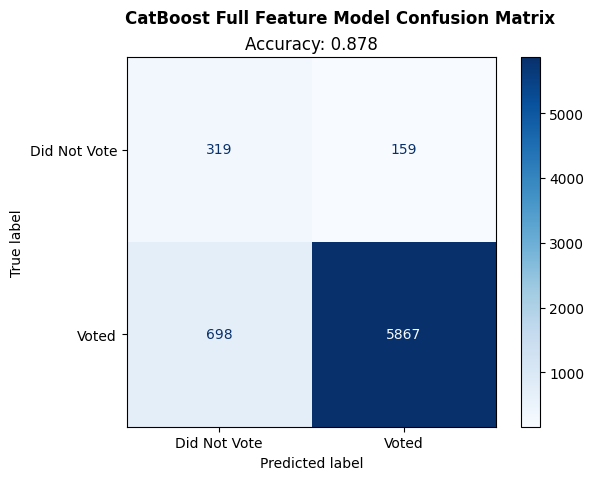

In [120]:
# confusion matrix
confusion_matrix_ex(y_val, val_preds, ["Did Not Vote", "Voted"], "CatBoost Full Feature Model")

CatBoost Full Feature Model Accuracy: 0.8783188981967911
CatBoost Full Feature Model ROC-AUC: 0.8750983884999379

Classification Report:
               precision    recall  f1-score   support

           0       0.31      0.67      0.43       478
           1       0.97      0.89      0.93      6565

    accuracy                           0.88      7043
   macro avg       0.64      0.78      0.68      7043
weighted avg       0.93      0.88      0.90      7043



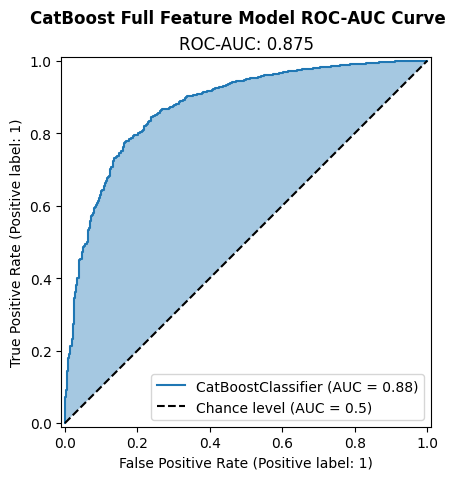

In [121]:
# roc curve
perf_output(cb_model, X_val, y_val, "CatBoost Full Feature Model")

In [122]:
# feature importance 
feat_imp = pd.Series(
    cb_model.get_feature_importance(),
    index=full_features
).sort_values(ascending=False)

print("\nTop 20 features:")
print(feat_imp.head(20))

print("\nBottom 10 features (candidates to drop):")
print(feat_imp.tail(10))


Top 20 features:
CC24_421_2     7.700297
CC24_431a      6.711244
pid7           4.493230
newsint        4.144420
marstat        3.968994
voted_2020     3.476637
ownhome        3.330239
educ           3.202813
VoterAge       3.201255
CC24_310a      2.978024
race           2.617782
CC24_421_1     2.483370
CC24_300d_6    2.479555
investor       2.210921
CC24_309d_1    2.118680
always_vote    2.042245
gender4        1.903696
IsParent       1.889811
edloan         1.845460
CC24_430a_8    1.827437
dtype: float64

Bottom 10 features (candidates to drop):
CC24_430a_6             0.0
CC24_430a_7             0.0
CC24_430a_1             0.0
CC24_430b_7             0.0
CC24_430b_10            0.0
CC24_430c               0.0
gunown                  0.0
CC24_430b_9             0.0
any_pol_social_media    0.0
any_media_use           0.0
dtype: float64


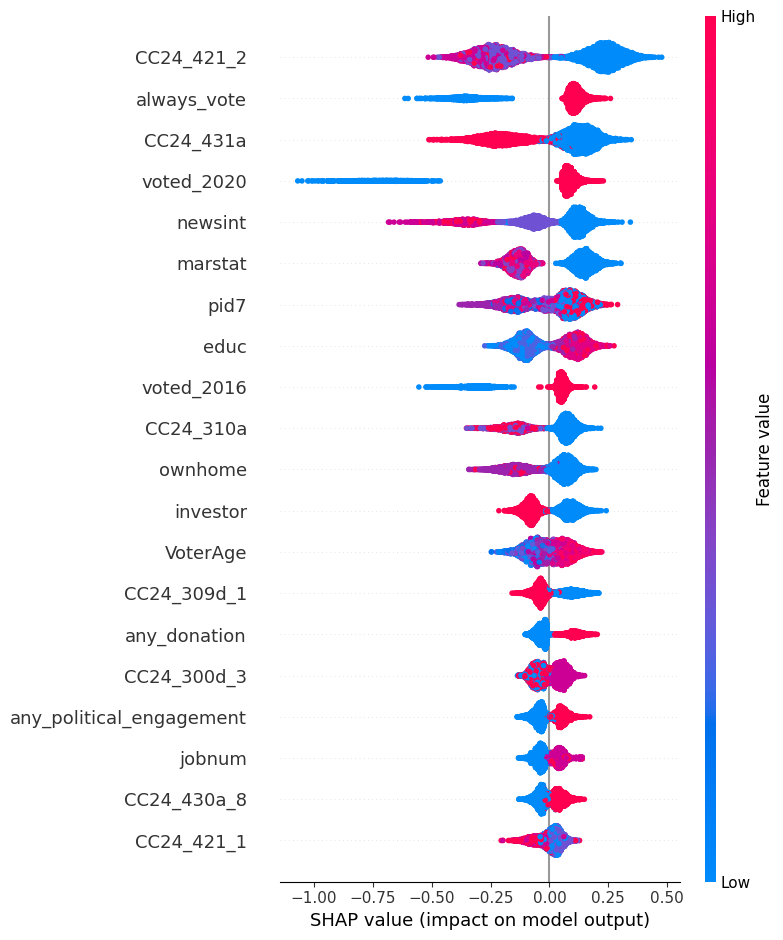

In [124]:
# compute shap values
explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_val)

shap_explaination = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_val,
    feature_names=full_features
)

# SHAP summary plot
shap.summary_plot(shap_values, X_val, feature_names=full_features, max_display=20)

In [137]:
# evaluate cb_model on test set
test_probs = cb_model.predict_proba(X_test)[:, 1]
test_preds = cb_model.predict(X_test)
print(f"\nTest AUC: {roc_auc_score(y_test, test_probs):.4f}")
print(classification_report(y_test, test_preds))


Test AUC: 0.8670
              precision    recall  f1-score   support

           0       0.28      0.63      0.39       478
           1       0.97      0.89      0.93      6565

    accuracy                           0.87      7043
   macro avg       0.63      0.76      0.66      7043
weighted avg       0.92      0.87      0.89      7043



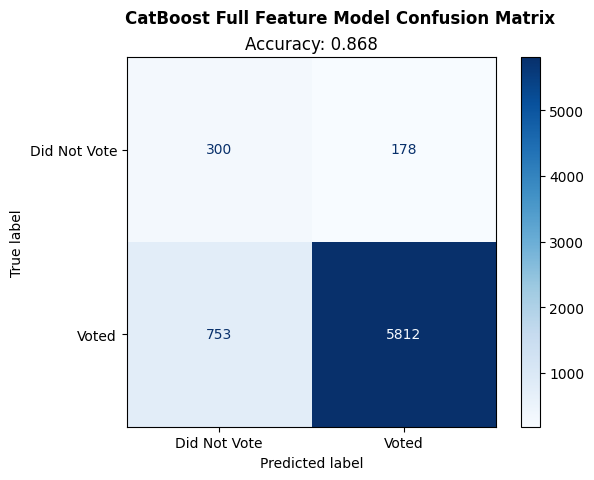

In [138]:
# confusion matrix
confusion_matrix_ex(y_test, test_preds, ["Did Not Vote", "Voted"], "CatBoost Full Feature Model")

CatBoost Full Feature Model Accuracy: 0.8678120119267357
CatBoost Full Feature Model ROC-AUC: 0.8670453495301251

Classification Report:
               precision    recall  f1-score   support

           0       0.28      0.63      0.39       478
           1       0.97      0.89      0.93      6565

    accuracy                           0.87      7043
   macro avg       0.63      0.76      0.66      7043
weighted avg       0.92      0.87      0.89      7043



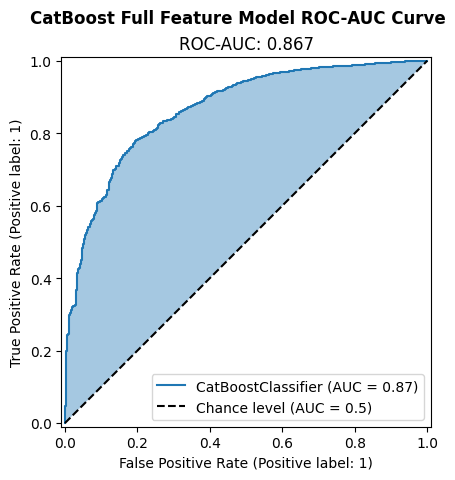

In [139]:
# roc curve
perf_output(cb_model, X_test, y_test, "CatBoost Full Feature Model")

## Feature pruning

In [128]:
# get feature importance from model
feat_imp = pd.Series(
    cb_model.get_feature_importance(),
    index=full_features
).sort_values(ascending=False)

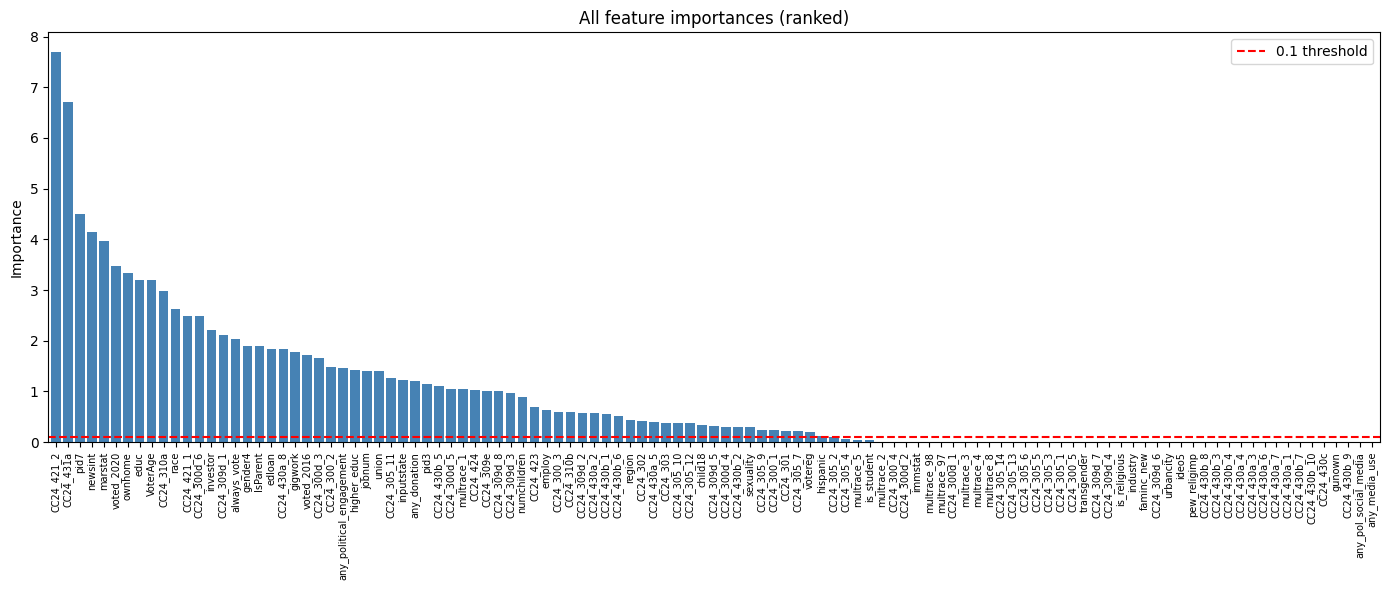

In [129]:
# visualize distribution
fig, axes = plt.subplots(figsize=(14, 6))

# Left: full ranked importance
feat_imp.plot(kind='bar', ax=axes, color='steelblue', width=0.8)
axes.set_title("All feature importances (ranked)")
axes.set_xlabel("")
axes.set_ylabel("Importance")
axes.tick_params(axis='x', labelsize=7)
axes.axhline(y=0.1, color='red', linestyle='--', label='0.1 threshold')
axes.legend()

plt.tight_layout()
plt.show()

In [130]:
# print pruning summary
print("=" * 55)
print(f"Total features: {len(feat_imp)}")
print("=" * 55)

for threshold in [0.05, 0.10, 0.20, 0.50]:
    to_drop = feat_imp[feat_imp < threshold]
    to_keep = feat_imp[feat_imp >= threshold]
    pct_importance_kept = feat_imp[feat_imp >= threshold].sum() / feat_imp.sum() * 100
    print(f"\nThreshold {threshold}:")
    print(f"  Keep: {len(to_keep):3d} features  |  "
          f"Drop: {len(to_drop):3d} features  |  "
          f"Importance retained: {pct_importance_kept:.1f}%")

Total features: 111

Threshold 0.05:
  Keep:  67 features  |  Drop:  44 features  |  Importance retained: 99.9%

Threshold 0.1:
  Keep:  65 features  |  Drop:  46 features  |  Importance retained: 99.7%

Threshold 0.2:
  Keep:  63 features  |  Drop:  48 features  |  Importance retained: 99.4%

Threshold 0.5:
  Keep:  48 features  |  Drop:  63 features  |  Importance retained: 94.6%


In [131]:
# with 0.1 threshold
THRESHOLD = 0.10   # <-- adjust after reviewing the plot

features_to_drop = feat_imp[feat_imp < THRESHOLD].index.tolist()
features_to_keep = feat_imp[feat_imp >= THRESHOLD].index.tolist()

print(f"\n── Features to DROP (importance < {THRESHOLD}) ──────────────────")
drop_df = feat_imp[features_to_drop].reset_index()
drop_df.columns = ['feature', 'importance']
print(drop_df.to_string(index=False))

print(f"\n── Top 20 features to KEEP ──────────────────────────────────────")
print(feat_imp.head(20).to_string())


── Features to DROP (importance < 0.1) ──────────────────
             feature  importance
          CC24_305_2    0.094260
          CC24_305_4    0.066626
          multrace_5    0.049667
          is_student    0.040565
          multrace_2    0.000000
          CC24_300_4    0.000000
         CC24_300d_2    0.000000
             immstat    0.000000
         multrace_98    0.000000
         multrace_97    0.000000
         CC24_300d_1    0.000000
          multrace_3    0.000000
          multrace_4    0.000000
          multrace_8    0.000000
         CC24_305_14    0.000000
         CC24_305_13    0.000000
          CC24_305_6    0.000000
          CC24_305_5    0.000000
          CC24_305_3    0.000000
          CC24_305_1    0.000000
          CC24_300_5    0.000000
         transgender    0.000000
         CC24_309d_7    0.000000
         CC24_309d_4    0.000000
        is_religious    0.000000
            industry    0.000000
          faminc_new    0.000000
         CC24_309

In [133]:
# retrain model with pruned features
NUMERIC_FEATURES = {'VoterAge', 'CC24_430c', 'numchildren', 'jobnum'}
cat_features_pruned = [f for f in features_to_keep if f not in NUMERIC_FEATURES]

pruned_model = CatBoostClassifier(
    cat_features=cat_features_pruned,
    **cb_best_params

)
pruned_model.fit(X_train[features_to_keep], y_train, eval_set=(X_val[features_to_keep], y_val), early_stopping_rounds=50)


0:	learn: 0.6394881	test: 0.6485775	best: 0.6485775 (0)	total: 580ms	remaining: 14m 26s
1:	learn: 0.5872867	test: 0.6121318	best: 0.6121318 (1)	total: 1.19s	remaining: 14m 46s
2:	learn: 0.5498126	test: 0.5826369	best: 0.5826369 (2)	total: 1.78s	remaining: 14m 46s
3:	learn: 0.5168613	test: 0.5615611	best: 0.5615611 (3)	total: 2.41s	remaining: 14m 59s
4:	learn: 0.4843421	test: 0.5426555	best: 0.5426555 (4)	total: 3.01s	remaining: 14m 56s
5:	learn: 0.4593771	test: 0.5282898	best: 0.5282898 (5)	total: 3.63s	remaining: 15m 1s
6:	learn: 0.4303696	test: 0.5178542	best: 0.5178542 (6)	total: 4.28s	remaining: 15m 9s
7:	learn: 0.4109315	test: 0.5087677	best: 0.5087677 (7)	total: 4.9s	remaining: 15m 11s
8:	learn: 0.3938430	test: 0.5013596	best: 0.5013596 (8)	total: 5.56s	remaining: 15m 19s
9:	learn: 0.3810517	test: 0.4936146	best: 0.4936146 (9)	total: 6.24s	remaining: 15m 26s
10:	learn: 0.3647500	test: 0.4889172	best: 0.4889172 (10)	total: 6.88s	remaining: 15m 29s
11:	learn: 0.3521789	test: 0.4854

CatBoostClassifier(auto_class_weights='Balanced', boosting_type='Plain', cat_features=['CC24_421_2', 'CC24_431a', 'pid7', 'newsint', 'marstat', 'voted_2020', 'ownhome', 'educ', 'CC24_310a', 'race', 'CC24_421_1', 'CC24_300d_6', 'investor', 'CC24_309d_1', 'always_vote', 'gender4', 'IsParent', 'edloan', 'CC24_430a_8', 'gigwork', 'voted_2016', 'CC24_300d_3', 'CC24_300_2', 'any_political_engagement', 'higher_educ', 'union', 'CC24_305_11', 'inputstate', 'any_donation', 'pid3', 'CC24_430b_5', 'CC24_300d_5', 'multrace_1', 'CC24_424', 'CC24_309e', 'CC24_309d_8', 'CC24_309d_3', 'CC24_423', 'employ', 'CC24_300_3', 'CC24_310b', 'CC24_309d_2', 'CC24_430a_2', 'CC24_430b_1', 'CC24_430b_6', 'region', 'CC24_302', 'CC24_430a_5', 'CC24_303', 'CC24_305_10', 'CC24_305_12', 'child18', 'CC24_309d_5', 'CC24_300d_4', 'CC24_430b_2', 'sexuality', 'CC24_305_9', 'CC24_300_1', 'CC24_301', 'CC24_305_7', 'votereg', 'hispanic'], colsample_bylevel=0.09936433478086192, depth=12, iterations=1496, l2_leaf_reg=4.7122896426

In [134]:
pruned_auc = roc_auc_score(y_val, pruned_model.predict_proba(X_val[features_to_keep])[:, 1])
original_auc = roc_auc_score(y_val, cb_model.predict_proba(X_val)[:, 1])

print(f"\n── AUC comparison ───────────────────────────────────────────────")
print(f"  Original  ({len(full_features):3d} features): {original_auc:.4f}")
print(f"  Pruned    ({len(features_to_keep):3d} features): {pruned_auc:.4f}")
print(f"  Difference:               {pruned_auc - original_auc:+.4f}")


── AUC comparison ───────────────────────────────────────────────
  Original  (111 features): 0.8751
  Pruned    ( 65 features): 0.8750
  Difference:               -0.0001


In [136]:
# evaluate on test set
test_probs = pruned_model.predict_proba(X_test[features_to_keep])[:, 1]
test_preds = pruned_model.predict(X_test[features_to_keep])
print(f"\nTest AUC: {roc_auc_score(y_test, test_probs):.4f}")
print(classification_report(y_test, test_preds))


Test AUC: 0.8604
              precision    recall  f1-score   support

           0       0.29      0.63      0.40       478
           1       0.97      0.89      0.93      6565

    accuracy                           0.87      7043
   macro avg       0.63      0.76      0.66      7043
weighted avg       0.92      0.87      0.89      7043

